# 01 — Análise Exploratória de Dados (EDA)

**Projeto:** PetFinder Intelligence  
**Autor:** Rennan Damiani  
**Objetivo:** Compreender o dataset antes de qualquer modelação. Esta EDA deve terminar com um conjunto claro de decisões de pré-processamento justificadas por evidência.

## Perguntas que queremos responder
1. Qual é a forma e qualidade dos dados?
2. Como está distribuído o target (AdoptionSpeed)?
3. O que distingue um animal de adoção rápida vs lenta?
4. As descrições textuais têm sinal?
5. As imagens têm sinal e qualidade suficientes?
6. Há fugas de dados ou armadilhas escondidas?
7. Que decisões saem daqui para o notebook 02?

In [1]:
# Imports base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuração visual
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100

# Reprodutibilidade
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Mostrar mais colunas/linhas quando inspecionamos dataframes
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

print("Setup OK")

Setup OK


In [2]:
# Caminhos relativos à raiz do projeto
# O notebook está em notebooks/, portanto subimos um nível
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"

TRAIN_CSV = DATA_DIR / "train" / "train.csv"
TRAIN_IMAGES_DIR = DATA_DIR / "train_images"
BREED_LABELS = DATA_DIR / "breed_labels.csv"
COLOR_LABELS = DATA_DIR / "color_labels.csv"
STATE_LABELS = DATA_DIR / "state_labels.csv"

# Verificação de sanidade — todos estes têm de existir
for name, path in [
    ("train.csv", TRAIN_CSV),
    ("train_images/", TRAIN_IMAGES_DIR),
    ("breed_labels.csv", BREED_LABELS),
    ("color_labels.csv", COLOR_LABELS),
    ("state_labels.csv", STATE_LABELS),
]:
    status = "✅" if path.exists() else "❌ NÃO ENCONTRADO"
    print(f"{status}  {name:25s} → {path}")

✅  train.csv                 → /Users/rennandamiani/Documents/ISAG/ProjetoFinal_PetFinder/data/train/train.csv
✅  train_images/             → /Users/rennandamiani/Documents/ISAG/ProjetoFinal_PetFinder/data/train_images
✅  breed_labels.csv          → /Users/rennandamiani/Documents/ISAG/ProjetoFinal_PetFinder/data/breed_labels.csv
✅  color_labels.csv          → /Users/rennandamiani/Documents/ISAG/ProjetoFinal_PetFinder/data/color_labels.csv
✅  state_labels.csv          → /Users/rennandamiani/Documents/ISAG/ProjetoFinal_PetFinder/data/state_labels.csv


In [3]:
df = pd.read_csv(TRAIN_CSV)

print(f"Shape: {df.shape[0]:,} linhas × {df.shape[1]} colunas")
print(f"Memória: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
df.head()

Shape: 14,993 linhas × 24 colunas
Memória: 11.63 MB


,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed
0,2,Nibble,3,299,0,1,1,7,0,1,1,2,2,2,1,1,100,41326,8480853f516546f6cf33aa88cd76c379,0,Nibble is a 3+ month old ball of cuteness. He ...,86e1089a3,1.0,2
1,2,No Name Yet,1,265,0,1,1,2,0,2,2,3,3,3,1,1,0,41401,3082c7125d8fb66f7dd4bff4192c8b14,0,I just found it alone yesterday near my apartm...,6296e909a,2.0,0
2,1,Brisco,1,307,0,1,2,7,0,2,2,1,1,2,1,1,0,41326,fa90fa5b1ee11c86938398b60abc32cb,0,Their pregnant mother was dumped by her irresp...,3422e4906,7.0,3
3,1,Miko,4,307,0,2,1,2,0,2,1,1,1,2,1,1,150,41401,9238e4f44c71a75282e62f7136c6b240,0,"Good guard dog, very alert, active, obedience ...",5842f1ff5,8.0,2
4,1,Hunter,1,307,0,1,1,0,0,2,1,2,2,2,1,1,0,41326,95481e953f8aed9ec3d16fc4509537e8,0,This handsome yet cute boy is up for adoption....,850a43f90,3.0,2


In [4]:
# Resumo compacto: tipo, n.º de não-nulos, n.º de únicos, % missing
summary = pd.DataFrame({
    "dtype": df.dtypes,
    "non_null": df.notna().sum(),
    "nulls": df.isna().sum(),
    "pct_missing": (df.isna().sum() / len(df) * 100).round(2),
    "n_unique": df.nunique(),
})
summary.sort_values("pct_missing", ascending=False)

,dtype,non_null,nulls,pct_missing,n_unique
Name,str,13728,1265,8.44,9059
Description,str,14980,13,0.09,14031
Type,int64,14993,0,0.00,2
PhotoAmt,float64,14993,0,0.00,31
PetID,str,14993,0,0.00,14993
VideoAmt,int64,14993,0,0.00,9
RescuerID,str,14993,0,0.00,5595
State,int64,14993,0,0.00,14
Fee,int64,14993,0,0.00,74
Quantity,int64,14993,0,0.00,19


## 2. O Target: AdoptionSpeed

A variável `AdoptionSpeed` tem 5 classes originais definidas pelo PetFinder:

- **0** — Adotado no mesmo dia da listagem
- **1** — Adotado entre 1 e 7 dias
- **2** — Adotado entre 8 e 30 dias
- **3** — Adotado entre 31 e 90 dias
- **4** — Não adotado após 100 dias

Para este projeto vamos binarizar em **Adoção Rápida** (classes 0, 1, 2) vs **Adoção Lenta** (classes 3, 4), por duas razões:
1. O projeto de Deep Learning anterior mostrou que 5 classes é um problema mal posto (ruído entre classes adjacentes)
2. A pergunta de negócio é binária: "este animal vai demorar?"

In [5]:
# Contagem absoluta e percentual
counts = df["AdoptionSpeed"].value_counts().sort_index()
pcts = df["AdoptionSpeed"].value_counts(normalize=True).sort_index() * 100

# Juntar num quadro legível
target_summary = pd.DataFrame({
    "Classe": counts.index,
    "Descrição": [
        "0 — Mesmo dia",
        "1 — 1 a 7 dias",
        "2 — 8 a 30 dias",
        "3 — 31 a 90 dias",
        "4 — Não adotado (100+ dias)",
    ],
    "Contagem": counts.values,
    "% do total": pcts.round(2).values,
})
target_summary

,Classe,Descrição,Contagem,% do total
0,0,0 — Mesmo dia,410,2.73
1,1,1 — 1 a 7 dias,3090,20.61
2,2,2 — 8 a 30 dias,4037,26.93
3,3,3 — 31 a 90 dias,3259,21.74
4,4,4 — Não adotado (100+ dias),4197,27.99


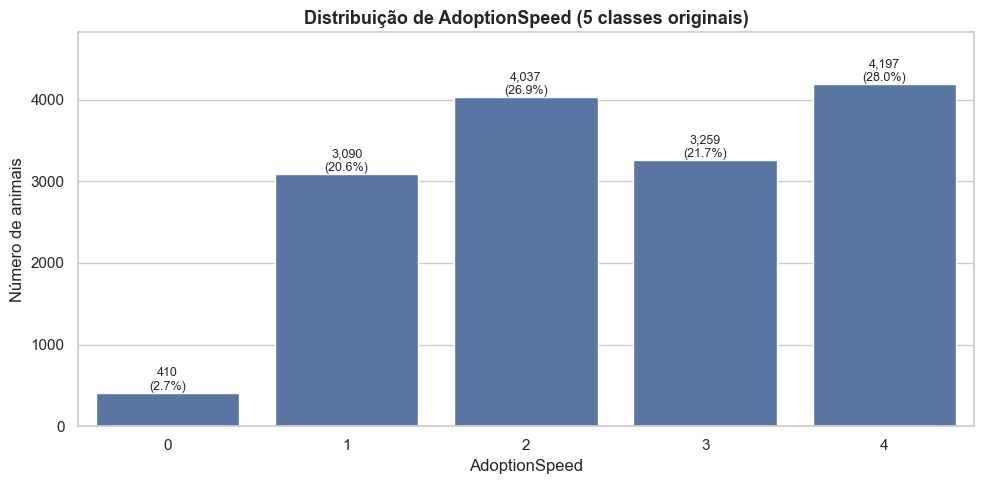

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

# Barplot com contagens
bars = sns.countplot(
    data=df,
    x="AdoptionSpeed",
    ax=ax,
    color="#4C72B0",
)

# Anotar cada barra com contagem e percentagem
total = len(df)
for patch in ax.patches:
    height = patch.get_height()
    pct = height / total * 100
    ax.annotate(
        f"{int(height):,}\n({pct:.1f}%)",
        xy=(patch.get_x() + patch.get_width() / 2, height),
        ha="center", va="bottom",
        fontsize=9,
    )

ax.set_title("Distribuição de AdoptionSpeed (5 classes originais)", fontsize=13, weight="bold")
ax.set_xlabel("AdoptionSpeed")
ax.set_ylabel("Número de animais")
ax.set_ylim(0, max(ax.patches, key=lambda p: p.get_height()).get_height() * 1.15)

plt.tight_layout()
plt.show()

In [7]:
# Binarização: 0, 1, 2 → Rápida (1); 3, 4 → Lenta (0)
# IMPORTANTE: codifico Rápida=1 porque é a "classe positiva" do ponto de vista de negócio
# (o que queremos prever: este animal vai ser adotado rapidamente?)
df["AdoptionFast"] = (df["AdoptionSpeed"] <= 2).astype(int)

# Verificação
print("Distribuição da nova variável binária:")
print(df["AdoptionFast"].value_counts().sort_index())
print()
print("Em percentagem:")
print((df["AdoptionFast"].value_counts(normalize=True).sort_index() * 100).round(2))
print()
print("Cross-check: confirmar que a binarização está correta")
print(pd.crosstab(df["AdoptionSpeed"], df["AdoptionFast"], margins=True))

Distribuição da nova variável binária:
AdoptionFast
0    7456
1    7537
Name: count, dtype: int64

Em percentagem:
AdoptionFast
0    49.73
1    50.27
Name: proportion, dtype: float64

Cross-check: confirmar que a binarização está correta
AdoptionFast      0     1    All
AdoptionSpeed                   
0                 0   410    410
1                 0  3090   3090
2                 0  4037   4037
3              3259     0   3259
4              4197     0   4197
All            7456  7537  14993


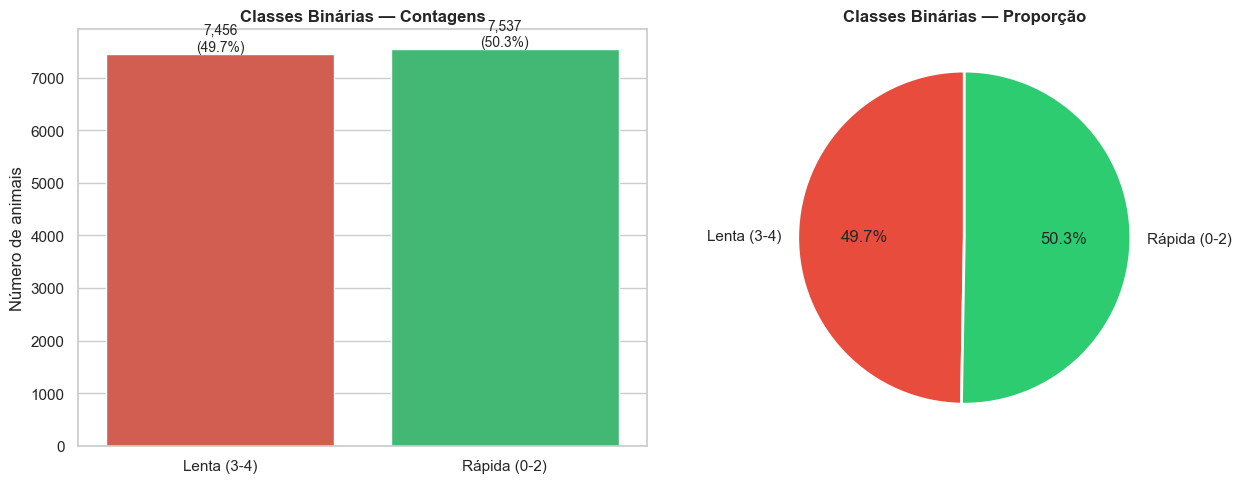

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Painel esquerdo: contagens
sns.countplot(
    data=df,
    x="AdoptionFast",
    ax=axes[0],
    palette=["#E74C3C", "#2ECC71"],
    hue="AdoptionFast",
    legend=False,
)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Lenta (3-4)", "Rápida (0-2)"])
axes[0].set_title("Classes Binárias — Contagens", weight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("Número de animais")

total = len(df)
for patch in axes[0].patches:
    height = patch.get_height()
    pct = height / total * 100
    axes[0].annotate(
        f"{int(height):,}\n({pct:.1f}%)",
        xy=(patch.get_x() + patch.get_width() / 2, height),
        ha="center", va="bottom", fontsize=10,
    )

# Painel direito: pie chart para reforçar o equilíbrio
counts_binary = df["AdoptionFast"].value_counts().sort_index()
axes[1].pie(
    counts_binary.values,
    labels=["Lenta (3-4)", "Rápida (0-2)"],
    autopct="%1.1f%%",
    colors=["#E74C3C", "#2ECC71"],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)
axes[1].set_title("Classes Binárias — Proporção", weight="bold")

plt.tight_layout()
plt.show()


### Decisões tomadas neste bloco

1. **Binarização confirmada:** `AdoptionSpeed <= 2` → `AdoptionFast = 1` (Rápida, classe positiva).
2. **Dataset balanceado** (ratio ≈ 1.01). Podemos usar `accuracy` como métrica principal, mas vamos reportar precision/recall/F1/AUC também.
3. **`AdoptionFast` fica no dataframe** — é o target oficial daqui para a frente. A `AdoptionSpeed` original mantém-se para referência mas não vai ser usada para treinar.

### Ainda em aberto
- A classe 0 ("mesmo dia") parece ser rara no conjunto original. Se quisermos um modelo de 5 classes no futuro, isso seria um problema. Para a binária, não é.

## 3. Features Tabulares

Vamos analisar as features por grupos, com foco em duas perguntas:
1. Como está distribuída cada feature?
2. Esta feature distingue animais de adoção rápida vs lenta?

Organização:
- **3.1** Numéricas contínuas (Age, Fee, PhotoAmt, VideoAmt, Quantity)
- **3.2** Categóricas ordinais (saúde, tamanho, pelagem)
- **3.3** Categóricas nominais (tipo, género, cores, raças, estado)
- **3.4** Identificadores e texto (tratados como features meta)

In [13]:
# Definir grupos semânticos de features — será útil em várias células
NUMERIC_CONT = ["Age", "Fee", "PhotoAmt", "VideoAmt", "Quantity"]

CATEGORICAL_ORDINAL = [
    "MaturitySize",   # 1=Small, 2=Medium, 3=Large, 4=Extra Large
    "FurLength",      # 1=Short, 2=Medium, 3=Long
    "Health",         # 1=Healthy, 2=Minor Injury, 3=Serious Injury
    "Vaccinated",     # 1=Yes, 2=No, 3=Not Sure
    "Dewormed",       # 1=Yes, 2=No, 3=Not Sure
    "Sterilized",     # 1=Yes, 2=No, 3=Not Sure
]

CATEGORICAL_NOMINAL = [
    "Type",           # 1=Dog, 2=Cat
    "Gender",         # 1=Male, 2=Female, 3=Mixed (grupo)
    "Color1", "Color2", "Color3",
    "Breed1", "Breed2",
    "State",
]

META_FEATURES = ["PetID", "Name", "RescuerID", "Description"]

# Confirmar que todas as features existem
all_features = NUMERIC_CONT + CATEGORICAL_ORDINAL + CATEGORICAL_NOMINAL + META_FEATURES + ["AdoptionSpeed", "AdoptionFast"]
missing = set(all_features) - set(df.columns)
extra = set(df.columns) - set(all_features)
print(f"Features em falta no df: {missing or 'nenhuma ✅'}")
print(f"Colunas não classificadas: {extra or 'nenhuma ✅'}")

Features em falta no df: nenhuma ✅
Colunas não classificadas: nenhuma ✅


In [14]:
df[NUMERIC_CONT].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Age,14993.0,10.45,18.16,0.0,2.0,3.0,12.0,255.0
Fee,14993.0,21.26,78.41,0.0,0.0,0.0,0.0,3000.0
PhotoAmt,14993.0,3.89,3.49,0.0,2.0,3.0,5.0,30.0
VideoAmt,14993.0,0.06,0.35,0.0,0.0,0.0,0.0,8.0
Quantity,14993.0,1.58,1.47,1.0,1.0,1.0,1.0,20.0


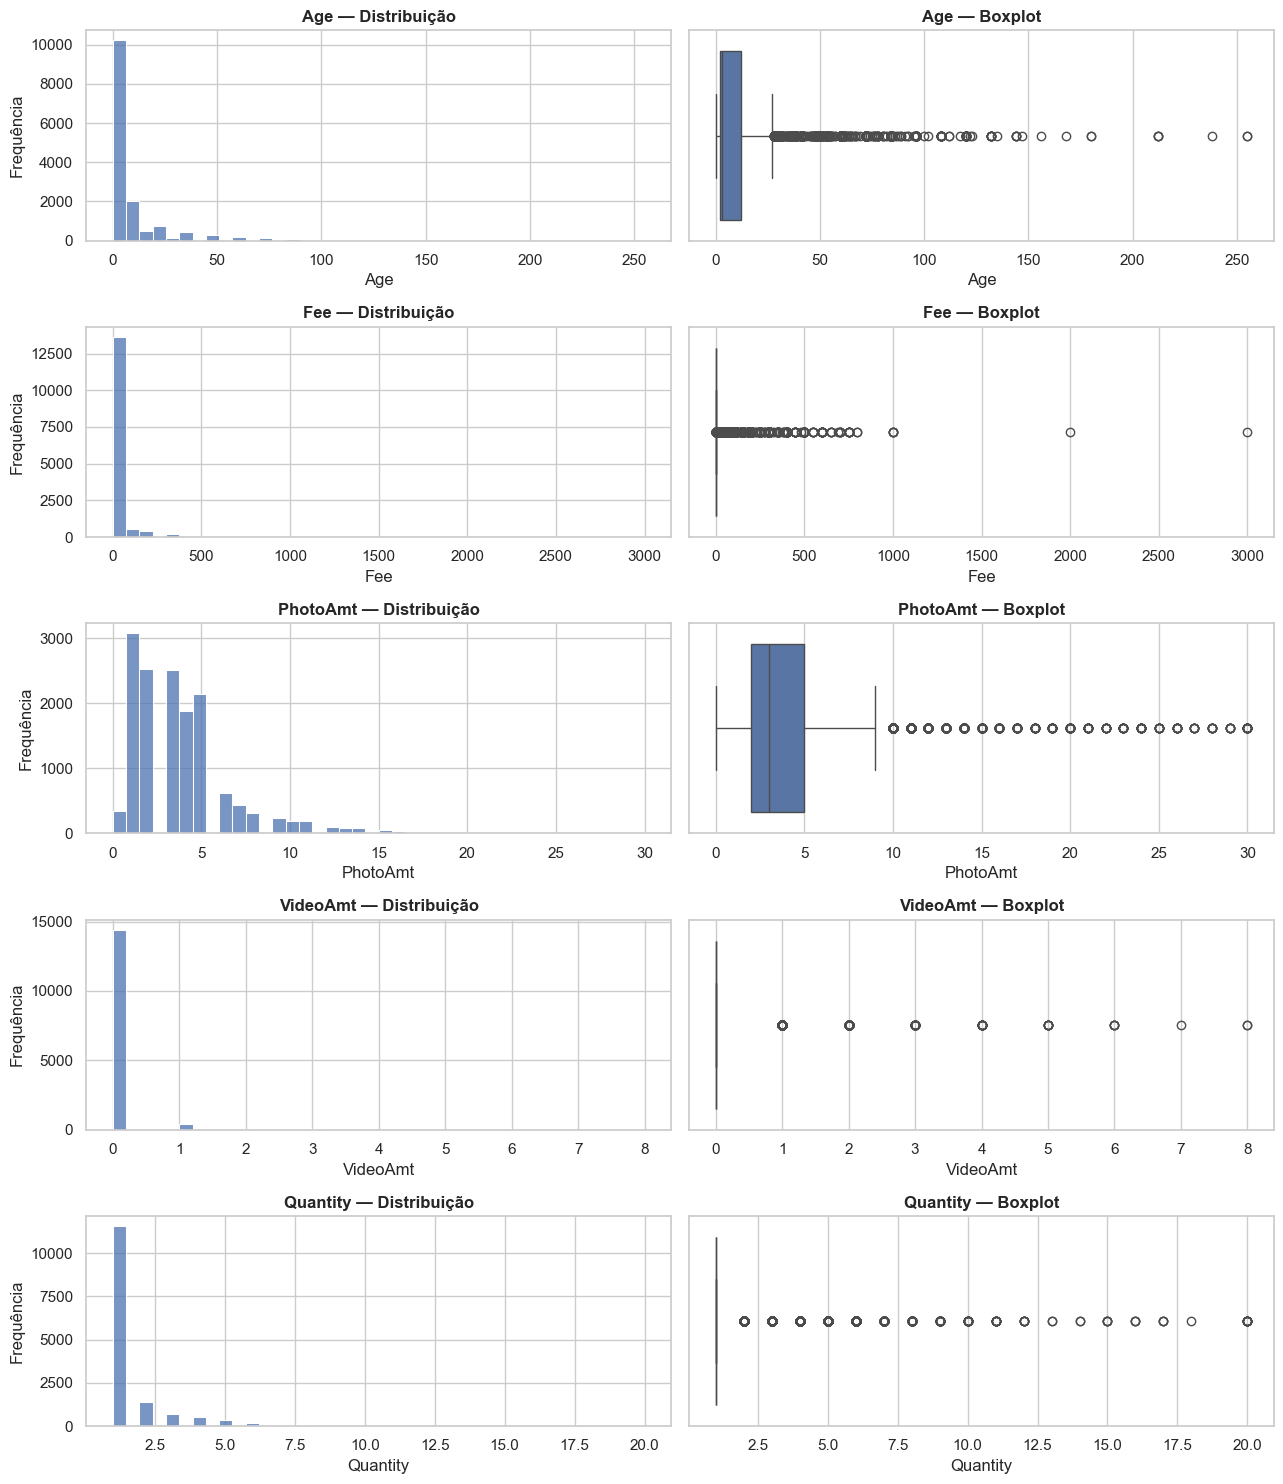

In [15]:
fig, axes = plt.subplots(len(NUMERIC_CONT), 2, figsize=(13, 3 * len(NUMERIC_CONT)))

for i, col in enumerate(NUMERIC_CONT):
    # Histograma (esquerda)
    sns.histplot(data=df, x=col, ax=axes[i, 0], bins=40, color="#4C72B0")
    axes[i, 0].set_title(f"{col} — Distribuição", weight="bold")
    axes[i, 0].set_ylabel("Frequência")

    # Boxplot (direita) — mais informativo para ver outliers
    sns.boxplot(data=df, x=col, ax=axes[i, 1], color="#4C72B0")
    axes[i, 1].set_title(f"{col} — Boxplot", weight="bold")

plt.tight_layout()
plt.show()

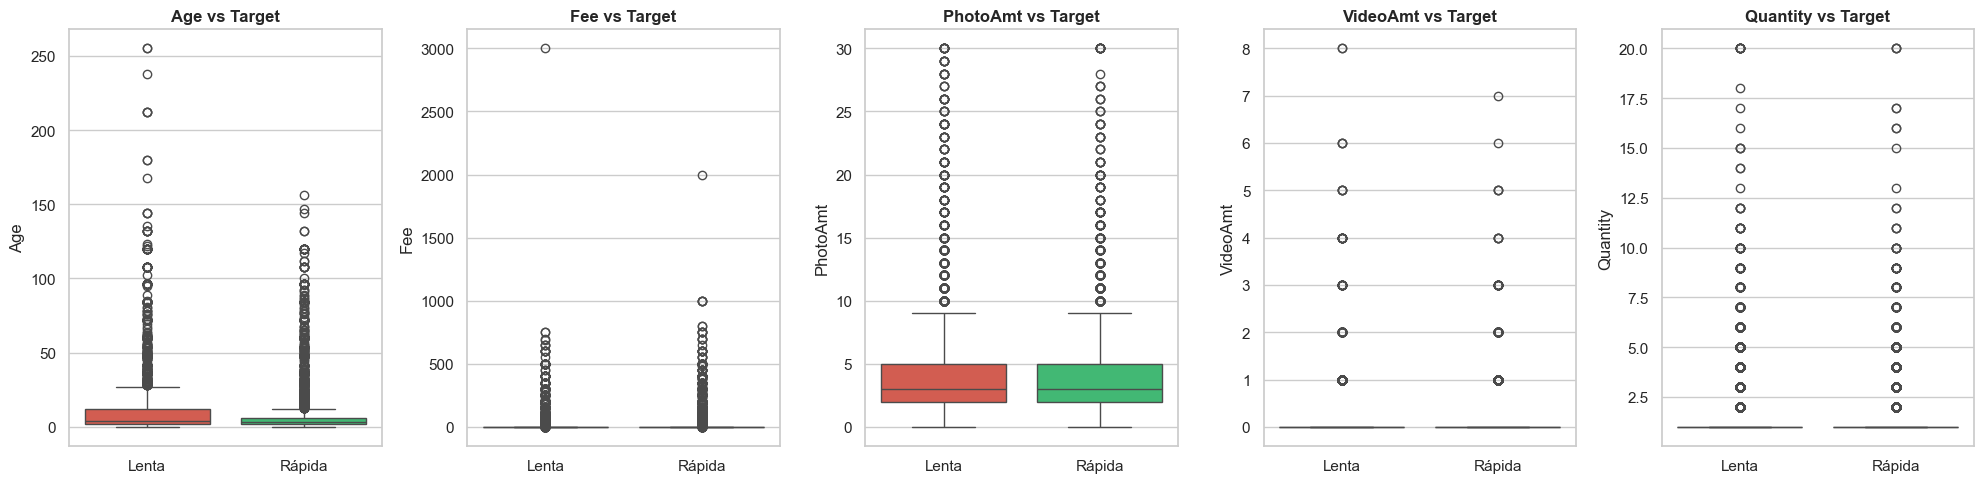

Média de cada feature por classe do target:


,Age,Fee,PhotoAmt,VideoAmt,Quantity
AdoptionFast,,,,,
0,12.15,20.81,3.89,0.06,1.64
1,8.77,21.71,3.89,0.06,1.51


In [16]:
fig, axes = plt.subplots(1, len(NUMERIC_CONT), figsize=(4 * len(NUMERIC_CONT), 5))

for i, col in enumerate(NUMERIC_CONT):
    sns.boxplot(
        data=df,
        x="AdoptionFast",
        y=col,
        ax=axes[i],
        palette=["#E74C3C", "#2ECC71"],
        hue="AdoptionFast",
        legend=False,
    )
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["Lenta", "Rápida"])
    axes[i].set_title(f"{col} vs Target", weight="bold")
    axes[i].set_xlabel("")

plt.tight_layout()
plt.show()

# Complementar com estatísticas numéricas
print("Média de cada feature por classe do target:")
df.groupby("AdoptionFast")[NUMERIC_CONT].mean().round(2)

In [17]:
from scipy.stats import mannwhitneyu

print("Teste Mann-Whitney U: as distribuições das numéricas diferem entre classes?")
print("(p < 0.05 → diferença estatisticamente significativa)\n")

results = []
for col in NUMERIC_CONT:
    group_fast = df.loc[df["AdoptionFast"] == 1, col]
    group_slow = df.loc[df["AdoptionFast"] == 0, col]
    stat, p = mannwhitneyu(group_fast, group_slow, alternative="two-sided")
    results.append({
        "Feature": col,
        "Mediana Rápida": group_fast.median(),
        "Mediana Lenta": group_slow.median(),
        "p-value": p,
        "Significativo (α=0.05)": "✅ Sim" if p < 0.05 else "❌ Não",
    })

pd.DataFrame(results).sort_values("p-value")

Teste Mann-Whitney U: as distribuições das numéricas diferem entre classes?
(p < 0.05 → diferença estatisticamente significativa)



,Feature,Mediana Rápida,Mediana Lenta,p-value,Significativo (α=0.05)
0,Age,3.0,4.0,4.743758e-114,✅ Sim
4,Quantity,1.0,1.0,6.191847e-07,✅ Sim
2,PhotoAmt,3.0,3.0,9.783018e-06,✅ Sim
1,Fee,0.0,0.0,1.593611e-01,❌ Não
3,VideoAmt,0.0,0.0,4.325386e-01,❌ Não


### Conclusões do bloco 3.1 (numéricas contínuas)

**Análise univariada:**
- **Age:** cauda longa até 255 meses (~21 anos). Mediana 3 meses (filhotes dominam). Distribuição válida, sem outliers a corrigir.
- **Fee:** fortemente zero-inflated. Mediana = Q75 = 0. Média 21.26 puxada por poucos valores altos (max 3000). Distribuição que só "vive" em duas modalidades: gratuito ou pago.
- **PhotoAmt:** discreta, quase toda entre 0 e 5. Mediana 3.
- **VideoAmt:** praticamente constante a 0 (média 0.06).
- **Quantity:** quase sempre 1, com casos isolados de ninhadas até 20 animais.

**Análise bivariada (vs AdoptionFast):**
- **Age:** 🟢 sinal forte. Animais lentos têm média 18.77 meses vs 12.15 dos rápidos (~55% mais velhos). p-value 4.7e-11.
- **Quantity:** 🟡 sinal estatisticamente significativo mas mediana idêntica (1.0 vs 1.0). Diferença vive nas caudas — ninhadas grandes podem correlacionar com adoção lenta.
- **PhotoAmt:** 🟡 mesmo padrão — significativo mas medianas idênticas. Sinal nas caudas.
- **Fee:** 🔴 sem diferença (p=0.159).
- **VideoAmt:** 🔴 sem diferença (p=0.433).

**Decisões preliminares para o notebook 02:**
- [x] **`VideoAmt` → dropar** ou binarizar `has_video`. Sem variabilidade, sem sinal.
- [x] **`Fee` → transformar em binária** `has_fee` (1 se >0, 0 caso contrário). A versão contínua não discrimina; a existência de taxa pode.
- [x] **`Age` → aplicar `log1p`** para comprimir a cauda longa, OU criar binning semântico (filhote<6m / jovem 6-24m / adulto 24-84m / sénior 84+m). Vamos testar as duas no baseline.
- [x] **`PhotoAmt` → manter**, mas registar que 341 animais têm zero fotos — estes vão ser problemáticos para o ramo visual da rede.
- [x] **`Quantity` → manter mas investigar o impacto de linhas com `Quantity>1`** no bloco 6 (armadilhas).

**Armadilha metodológica detetada:**
- Linhas com `Quantity>1` representam ninhadas/grupos. As imagens e descrições referem-se ao conjunto, não a cada animal. **Temos de decidir no bloco 6:** filtrar só `Quantity==1`? Manter e aceitar o ruído? Precisamos de ver quantos são.

## 3.2 Categóricas Ordinais

Features com ordem semântica. Esperamos que as de saúde/cuidados veterinários (Vaccinated, Dewormed, Sterilized) sejam preditoras fortes — animais com cuidados completos devem adotar-se mais rápido.

**Codificação do dataset (do data dictionary do Kaggle):**
- `MaturitySize`: 0=Not Specified, 1=Small, 2=Medium, 3=Large, 4=Extra Large
- `FurLength`: 0=Not Specified, 1=Short, 2=Medium, 3=Long
- `Health`: 0=Not Specified, 1=Healthy, 2=Minor Injury, 3=Serious Injury
- `Vaccinated` / `Dewormed` / `Sterilized`: 1=Yes, 2=No, 3=Not Sure

In [18]:
# Mapas de descodificação — úteis para gráficos e relatórios
MAPS = {
    "MaturitySize": {0: "N/A", 1: "Small", 2: "Medium", 3: "Large", 4: "XL"},
    "FurLength": {0: "N/A", 1: "Short", 2: "Medium", 3: "Long"},
    "Health": {0: "N/A", 1: "Healthy", 2: "Minor Injury", 3: "Serious Injury"},
    "Vaccinated": {1: "Yes", 2: "No", 3: "Not Sure"},
    "Dewormed": {1: "Yes", 2: "No", 3: "Not Sure"},
    "Sterilized": {1: "Yes", 2: "No", 3: "Not Sure"},
}

# Distribuição de cada feature ordinal
for col in CATEGORICAL_ORDINAL:
    counts = df[col].value_counts().sort_index()
    pcts = (df[col].value_counts(normalize=True).sort_index() * 100).round(1)
    labels = [MAPS[col].get(v, str(v)) for v in counts.index]

    print(f"\n── {col} " + "─" * (50 - len(col)))
    for val, label, n, pct in zip(counts.index, labels, counts.values, pcts.values):
        print(f"  {val} ({label:15s}): {n:5,} ({pct:5.1f}%)")


── MaturitySize ──────────────────────────────────────
  1 (Small          ): 3,395 ( 22.6%)
  2 (Medium         ): 10,305 ( 68.7%)
  3 (Large          ): 1,260 (  8.4%)
  4 (XL             ):    33 (  0.2%)

── FurLength ─────────────────────────────────────────
  1 (Short          ): 8,808 ( 58.7%)
  2 (Medium         ): 5,361 ( 35.8%)
  3 (Long           ):   824 (  5.5%)

── Health ────────────────────────────────────────────
  1 (Healthy        ): 14,478 ( 96.6%)
  2 (Minor Injury   ):   481 (  3.2%)
  3 (Serious Injury ):    34 (  0.2%)

── Vaccinated ────────────────────────────────────────
  1 (Yes            ): 5,898 ( 39.3%)
  2 (No             ): 7,227 ( 48.2%)
  3 (Not Sure       ): 1,868 ( 12.5%)

── Dewormed ──────────────────────────────────────────
  1 (Yes            ): 8,397 ( 56.0%)
  2 (No             ): 4,815 ( 32.1%)
  3 (Not Sure       ): 1,781 ( 11.9%)

── Sterilized ────────────────────────────────────────
  1 (Yes            ): 3,101 ( 20.7%)
  2 (No         

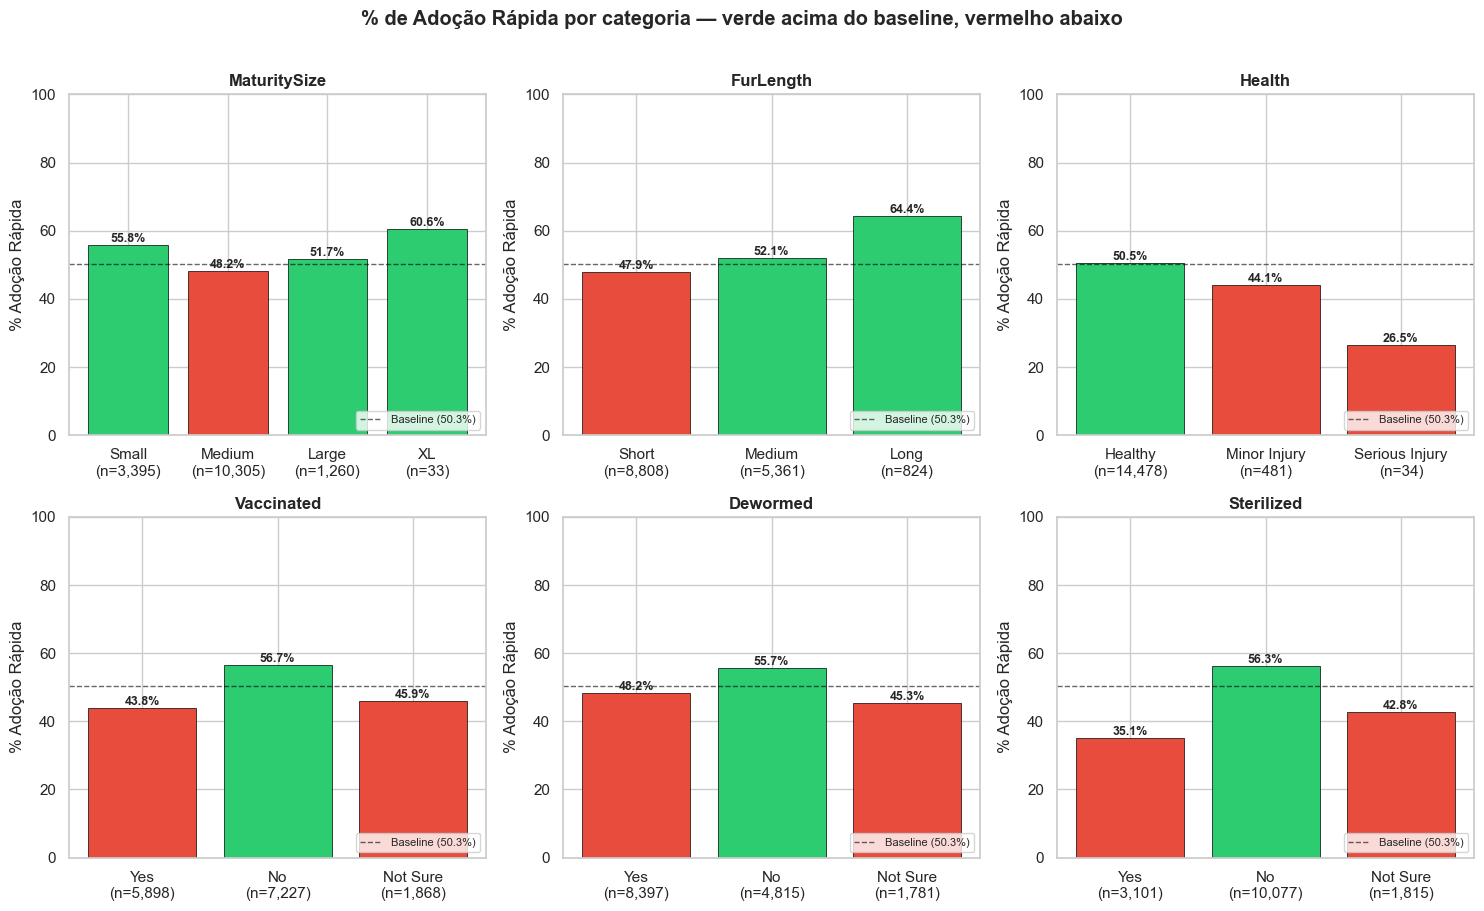

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

# Baseline global
baseline = df["AdoptionFast"].mean() * 100

for i, col in enumerate(CATEGORICAL_ORDINAL):
    # Calcular % de adoção rápida por categoria
    pct_rapida = df.groupby(col)["AdoptionFast"].mean() * 100
    n_por_cat = df.groupby(col).size()

    # Renomear índice
    labels = [f"{MAPS[col].get(v, str(v))}\n(n={n_por_cat[v]:,})" for v in pct_rapida.index]

    # Cor: verde se acima do baseline, vermelho se abaixo
    colors = ["#2ECC71" if v >= baseline else "#E74C3C" for v in pct_rapida.values]

    bars = axes[i].bar(labels, pct_rapida.values, color=colors, edgecolor="black", linewidth=0.5)

    # Linha do baseline
    axes[i].axhline(baseline, color="black", linestyle="--", linewidth=1, alpha=0.6,
                    label=f"Baseline ({baseline:.1f}%)")

    # Anotar cada barra
    for bar, val in zip(bars, pct_rapida.values):
        axes[i].annotate(
            f"{val:.1f}%",
            xy=(bar.get_x() + bar.get_width() / 2, val),
            ha="center", va="bottom",
            fontsize=9, weight="bold",
        )

    axes[i].set_title(f"{col}", weight="bold")
    axes[i].set_ylabel("% Adoção Rápida")
    axes[i].set_ylim(0, 100)
    axes[i].tick_params(axis="x", rotation=0)
    axes[i].legend(loc="lower right", fontsize=8)

plt.suptitle(
    "% de Adoção Rápida por categoria — verde acima do baseline, vermelho abaixo",
    weight="bold", y=1.01,
)
plt.tight_layout()
plt.show()

In [20]:
from scipy.stats import chi2_contingency

print("Teste Qui-quadrado: categoria e target são independentes?")
print("(p < 0.05 → há associação significativa)\n")

results = []
for col in CATEGORICAL_ORDINAL:
    ct = pd.crosstab(df[col], df["AdoptionFast"])
    chi2, p, dof, expected = chi2_contingency(ct)

    # Cramér's V — mede a força da associação (0 a 1)
    n = ct.values.sum()
    min_dim = min(ct.shape) - 1
    cramer_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0

    results.append({
        "Feature": col,
        "chi²": round(chi2, 2),
        "p-value": p,
        "Cramér's V": round(cramer_v, 3),
        "Força": (
            "Forte" if cramer_v >= 0.25 else
            "Moderada" if cramer_v >= 0.15 else
            "Fraca" if cramer_v >= 0.05 else
            "Desprezável"
        ),
    })

pd.DataFrame(results).sort_values("Cramér's V", ascending=False)

Teste Qui-quadrado: categoria e target são independentes?
(p < 0.05 → há associação significativa)



,Feature,chi²,p-value,Cramér's V,Força
5,Sterilized,468.94,1.479308e-102,0.177,Moderada
3,Vaccinated,230.61,8.387700e-51,0.124,Fraca
1,FurLength,93.64,4.637216e-21,0.079,Fraca
4,Dewormed,88.25,6.876072e-20,0.077,Fraca
0,MaturitySize,60.26,5.164534e-13,0.063,Fraca
2,Health,15.49,4.339833e-04,0.032,Desprezável


### Conclusões do bloco 3.2 (categóricas ordinais)

**Features com sinal moderado:**
- **Sterilized (Cramér's V = 0.177):** feature mais preditiva do bloco. **Atenção:** sinal parcialmente confundido com Age — esterilizam-se animais mais velhos, que adotam mais devagar. O modelo vai ter de separar estes dois sinais.

**Features com sinal fraco mas aproveitável:**
- **Vaccinated (0.124)**, **FurLength (0.079)**, **Dewormed (0.077)**, **MaturitySize (0.063)** — todas contribuem individualmente pouco mas o efeito agregado pode ser relevante. Manter todas.

**Features com sinal desprezável no agregado:**
- **Health (0.032):** 96.6% são "Healthy", o que dilui o cálculo. Mas para os ~515 animais com lesão, é altamente informativa. **Manter** — o custo de uma feature com baixa variância é baixo.

**Padrões confirmados visualmente:**
- `Sterilized=Yes` → adoção mais lenta (confounding com idade).
- `Health=Serious Injury` → adoção muito mais lenta (34 casos, efeito local forte).
- `FurLength=Long` → adoção mais rápida (apelo estético).

**Decisões para o notebook 02:**
- [x] Manter todas as 6 features ordinais como inteiros (a ordem tem significado).
- [x] **Consideração importante para interpretação**: no modelo final, usar SHAP ou permutation importance para separar o efeito de `Sterilized` do efeito de `Age` — sem isso, podemos concluir erradamente que "esterilizar faz mal à adoção".
- [x] Não dropar `Health` apesar do Cramér's V baixo — tem sinal local forte e o custo é mínimo.

## 3.3 Categóricas Nominais

Features sem ordem natural, tratadas por cardinalidade:

| Feature | Cardinalidade | Estratégia |
|---------|---------------|------------|
| Type | 2 | Análise direta |
| Gender | 3 | Análise direta |
| Color1/2/3 | ~7 | Análise direta com descodificação |
| State | 14 | Análise direta com descodificação |
| Breed1 | 176 | Top-N + bucket "Outras" |
| Breed2 | 135 | Top-N + bucket "Outras" |

**Perguntas:**
1. Cães e gatos adotam-se à mesma velocidade?
2. Há géneros preferidos?
3. Há cores ou raças claramente favorecidas?
4. A geografia (State) afeta a adoção?

In [22]:
# Carregar os ficheiros de descodificação
breed_labels = pd.read_csv(BREED_LABELS)
color_labels = pd.read_csv(COLOR_LABELS)
state_labels = pd.read_csv(STATE_LABELS)

print("── breed_labels ──")
print(breed_labels.head())
print(f"Total raças: {len(breed_labels)}\n")

print("── color_labels ──")
print(color_labels)
print()

print("── state_labels ──")
print(state_labels)

── breed_labels ──
   BreedID  Type         BreedName
0        1     1     Affenpinscher
1        2     1      Afghan Hound
2        3     1  Airedale Terrier
3        4     1            Akbash
4        5     1             Akita
Total raças: 307

── color_labels ──
   ColorID ColorName
0        1     Black
1        2     Brown
2        3    Golden
3        4    Yellow
4        5     Cream
5        6      Gray
6        7     White

── state_labels ──
    StateID        StateName
0     41336            Johor
1     41325            Kedah
2     41367         Kelantan
3     41401     Kuala Lumpur
4     41415           Labuan
5     41324           Melaka
6     41332  Negeri Sembilan
7     41335           Pahang
8     41330            Perak
9     41380           Perlis
10    41327     Pulau Pinang
11    41345            Sabah
12    41342          Sarawak
13    41326         Selangor
14    41361       Terengganu


In [23]:
# Assumindo nomes padrão — ajustar se o print acima mostrar outros
# (tipicamente: BreedID, BreedName / ColorID, ColorName / StateID, StateName)

breed_map = dict(zip(breed_labels["BreedID"], breed_labels["BreedName"]))
color_map = dict(zip(color_labels["ColorID"], color_labels["ColorName"]))
state_map = dict(zip(state_labels["StateID"], state_labels["StateName"]))

# Adicionar o valor 0 como "None/Unknown" para Breed2, Color2, Color3 (que permitem ausência)
breed_map[0] = "None"
color_map[0] = "None"

print(f"Exemplo — Breed1=1 traduz para: {breed_map.get(1, '??')}")
print(f"Exemplo — Color1=1 traduz para: {color_map.get(1, '??')}")
print(f"Exemplo — State={df['State'].iloc[0]} traduz para: {state_map.get(df['State'].iloc[0], '??')}")

Exemplo — Breed1=1 traduz para: Affenpinscher
Exemplo — Color1=1 traduz para: Black
Exemplo — State=41326 traduz para: Selangor


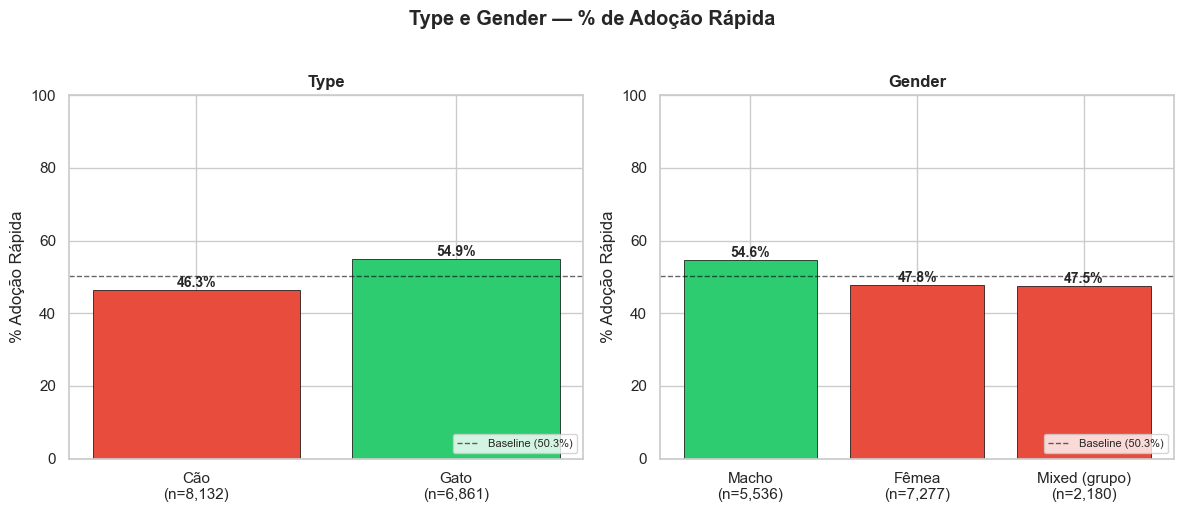

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
baseline = df["AdoptionFast"].mean() * 100

# Mapas legíveis
type_map = {1: "Cão", 2: "Gato"}
gender_map = {1: "Macho", 2: "Fêmea", 3: "Mixed (grupo)"}

for ax, col, mapping in zip(axes, ["Type", "Gender"], [type_map, gender_map]):
    pct = df.groupby(col)["AdoptionFast"].mean() * 100
    n = df.groupby(col).size()
    labels = [f"{mapping.get(v, str(v))}\n(n={n[v]:,})" for v in pct.index]
    colors = ["#2ECC71" if v >= baseline else "#E74C3C" for v in pct.values]

    bars = ax.bar(labels, pct.values, color=colors, edgecolor="black", linewidth=0.5)
    ax.axhline(baseline, color="black", linestyle="--", linewidth=1, alpha=0.6,
               label=f"Baseline ({baseline:.1f}%)")

    for bar, val in zip(bars, pct.values):
        ax.annotate(f"{val:.1f}%",
                    xy=(bar.get_x() + bar.get_width() / 2, val),
                    ha="center", va="bottom", fontsize=10, weight="bold")

    ax.set_title(f"{col}", weight="bold")
    ax.set_ylabel("% Adoção Rápida")
    ax.set_ylim(0, 100)
    ax.legend(loc="lower right", fontsize=8)

plt.suptitle("Type e Gender — % de Adoção Rápida", weight="bold", y=1.02)
plt.tight_layout()
plt.show()

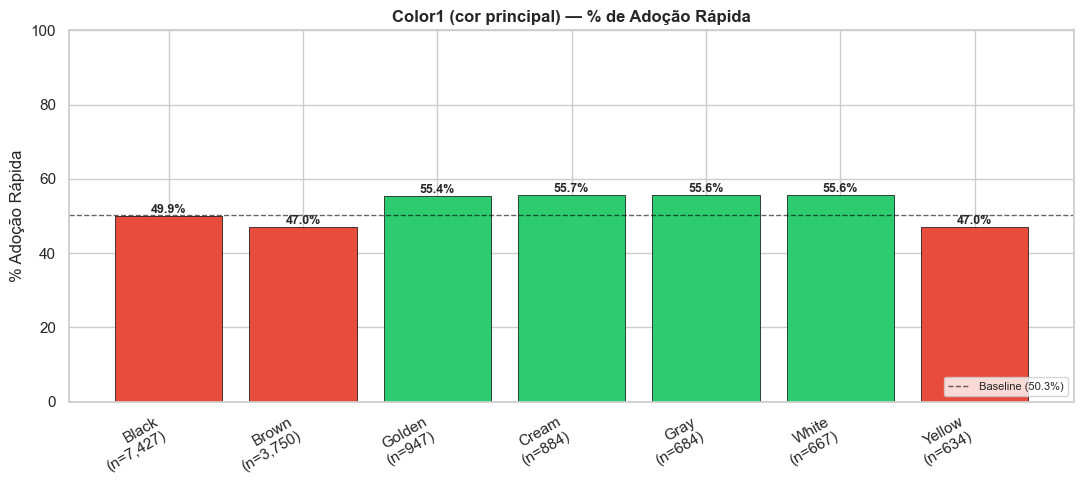

In [25]:
# Usar apenas Color1 (a cor principal). Color2/3 são ausentes em muitos animais.
col = "Color1"
df["_color1_label"] = df[col].map(color_map)

fig, ax = plt.subplots(figsize=(11, 5))

pct = df.groupby("_color1_label")["AdoptionFast"].mean() * 100
n = df.groupby("_color1_label").size()

# Ordenar por frequência decrescente
order = n.sort_values(ascending=False).index
pct = pct.reindex(order)
n = n.reindex(order)

labels = [f"{lbl}\n(n={n[lbl]:,})" for lbl in pct.index]
colors = ["#2ECC71" if v >= baseline else "#E74C3C" for v in pct.values]

bars = ax.bar(labels, pct.values, color=colors, edgecolor="black", linewidth=0.5)
ax.axhline(baseline, color="black", linestyle="--", linewidth=1, alpha=0.6,
           label=f"Baseline ({baseline:.1f}%)")

for bar, val in zip(bars, pct.values):
    ax.annotate(f"{val:.1f}%",
                xy=(bar.get_x() + bar.get_width() / 2, val),
                ha="center", va="bottom", fontsize=9, weight="bold")

ax.set_title("Color1 (cor principal) — % de Adoção Rápida", weight="bold")
ax.set_ylabel("% Adoção Rápida")
ax.set_ylim(0, 100)
ax.legend(loc="lower right", fontsize=8)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# Limpar coluna temporária
df.drop(columns=["_color1_label"], inplace=True)

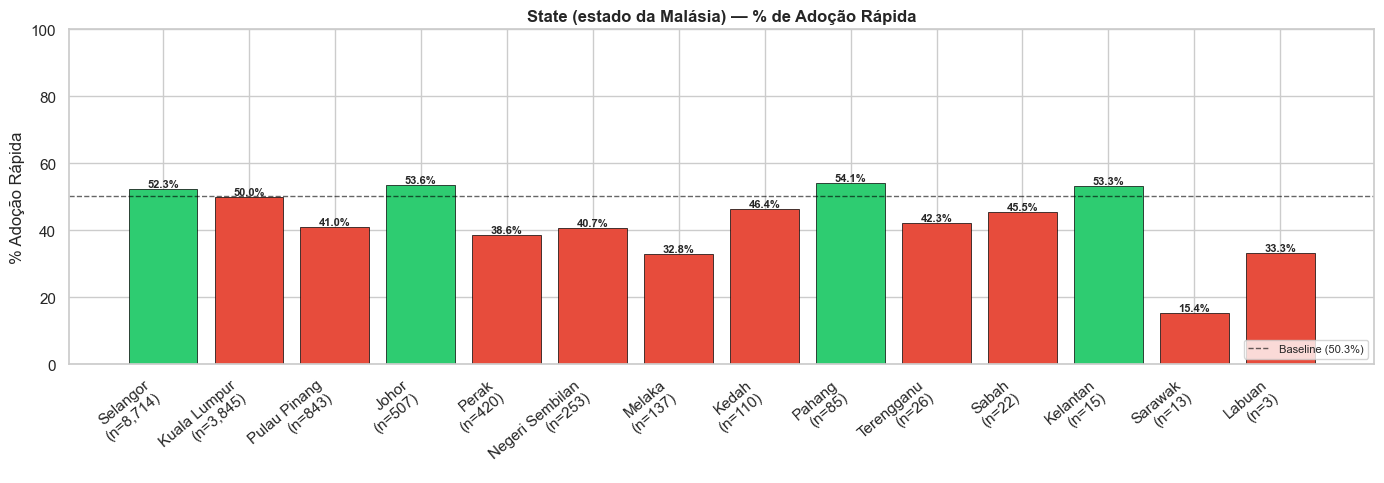


Top 3 estados representam: 89.4% do dataset


In [26]:
col = "State"
df["_state_label"] = df[col].map(state_map)

fig, ax = plt.subplots(figsize=(14, 5))

pct = df.groupby("_state_label")["AdoptionFast"].mean() * 100
n = df.groupby("_state_label").size()

order = n.sort_values(ascending=False).index
pct = pct.reindex(order)
n = n.reindex(order)

labels = [f"{lbl}\n(n={n[lbl]:,})" for lbl in pct.index]
colors = ["#2ECC71" if v >= baseline else "#E74C3C" for v in pct.values]

bars = ax.bar(labels, pct.values, color=colors, edgecolor="black", linewidth=0.5)
ax.axhline(baseline, color="black", linestyle="--", linewidth=1, alpha=0.6,
           label=f"Baseline ({baseline:.1f}%)")

for bar, val in zip(bars, pct.values):
    ax.annotate(f"{val:.1f}%",
                xy=(bar.get_x() + bar.get_width() / 2, val),
                ha="center", va="bottom", fontsize=8, weight="bold")

ax.set_title("State (estado da Malásia) — % de Adoção Rápida", weight="bold")
ax.set_ylabel("% Adoção Rápida")
ax.set_ylim(0, 100)
ax.legend(loc="lower right", fontsize=8)
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()

# Estatística adicional: quão concentrado está o dataset?
print("\nTop 3 estados representam: "
      f"{(n.sort_values(ascending=False).head(3).sum() / n.sum() * 100):.1f}% do dataset")

df.drop(columns=["_state_label"], inplace=True)

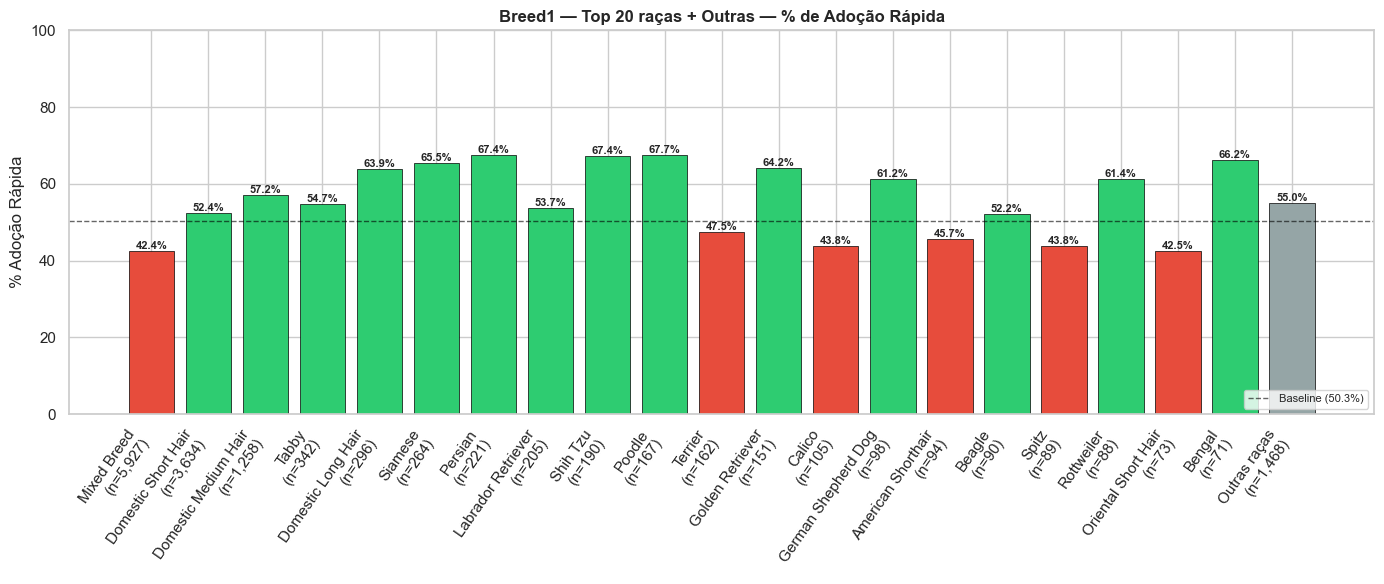


Animais em 'Outras raças': 1,468 (9.8% do dataset)
Top 20 raças cobrem: 90.2% do dataset


In [27]:
# Breed1 tem 176 valores únicos. Estratégia: top-20 + bucket "Outras"
col = "Breed1"
TOP_N = 20

df["_breed1_label"] = df[col].map(breed_map)

# Identificar as top-N raças mais frequentes
top_breeds = df["_breed1_label"].value_counts().head(TOP_N).index.tolist()

# Criar coluna agrupada
df["_breed1_grouped"] = df["_breed1_label"].where(
    df["_breed1_label"].isin(top_breeds),
    other="Outras raças"
)

fig, ax = plt.subplots(figsize=(14, 6))

pct = df.groupby("_breed1_grouped")["AdoptionFast"].mean() * 100
n = df.groupby("_breed1_grouped").size()

# Ordenar por frequência decrescente, mas "Outras raças" fica sempre no fim
order = [b for b in n.sort_values(ascending=False).index if b != "Outras raças"] + ["Outras raças"]
pct = pct.reindex(order)
n = n.reindex(order)

labels = [f"{lbl}\n(n={n[lbl]:,})" for lbl in pct.index]
colors = ["#2ECC71" if v >= baseline else "#E74C3C" for v in pct.values]
# "Outras" em cinzento para não confundir com as outras categorias
colors[-1] = "#95A5A6"

bars = ax.bar(labels, pct.values, color=colors, edgecolor="black", linewidth=0.5)
ax.axhline(baseline, color="black", linestyle="--", linewidth=1, alpha=0.6,
           label=f"Baseline ({baseline:.1f}%)")

for bar, val in zip(bars, pct.values):
    ax.annotate(f"{val:.1f}%",
                xy=(bar.get_x() + bar.get_width() / 2, val),
                ha="center", va="bottom", fontsize=8, weight="bold")

ax.set_title(f"Breed1 — Top {TOP_N} raças + Outras — % de Adoção Rápida", weight="bold")
ax.set_ylabel("% Adoção Rápida")
ax.set_ylim(0, 100)
ax.legend(loc="lower right", fontsize=8)
plt.xticks(rotation=55, ha="right")
plt.tight_layout()
plt.show()

# Quantos animais ficam fora do top-N
n_outside = (df["_breed1_grouped"] == "Outras raças").sum()
print(f"\nAnimais em 'Outras raças': {n_outside:,} ({n_outside/len(df)*100:.1f}% do dataset)")
print(f"Top {TOP_N} raças cobrem: {(1 - n_outside/len(df))*100:.1f}% do dataset")

df.drop(columns=["_breed1_label", "_breed1_grouped"], inplace=True)

### Conclusões do bloco 3.3 (categóricas nominais)

**🟢 Type (sinal forte):**
- Gatos têm adoção rápida ≈ 55%, cães ≈ 46%. Diferença de ~9pp — o maior efeito univariado tabular até agora.
- Candidato número 1 a preditor forte isolado.
- **Atenção a confounding:** a diferença pode estar parcialmente a capturar diferenças em outras features (Age, raças disponíveis, etc.). Investigar no bloco de modelação.

**🟡 Gender (sinal fraco):**
- `Mixed (grupo)` próximo do baseline (47.5%). Pouca diferenciação entre Macho/Fêmea.

**🔴 Color1 (sinal desprezável):**
- Variação máxima ±5pp em torno do baseline.
- A "black dog/cat syndrome" NÃO aparece neste dataset (contexto cultural malaio pode diferir).
- Manter por baixo custo, sem expectativas.

**🟡 State (sinal fraco, mas dataset enviesado):**
- Apenas 4 estados acima do baseline, máximo a 54%.
- **Top 3 estados = 89.4% do dataset** → forte concentração geográfica.
- Candidata a agrupamento em 3-4 buckets.

**⚠️ Breed1 (feature a reestruturar):**
- Top 3 valores: "Mixed Breed", "Domestic Short Hair", "Outras raças" → a maioria do dataset.
- "Mixed Breed" e "Domestic Short Hair" não são raças, são "sem raça pura" para cães e gatos.
- Top-20 cobre 90.2% — o bucket funciona.
- **Feature engineering proposto:** criar `is_mixed_breed` (binária) em vez de usar a raça bruta. Raças puras podem entrar como top-20 one-hot.

**Decisões para o notebook 02:**
- [x] **Criar feature `is_mixed_breed`:** 1 se `Breed1 ∈ {Mixed Breed, Domestic Short Hair}`, 0 caso contrário.
- [x] **Agrupar `State`** em 4 buckets: top 3 estados individualmente + "Outros".
- [x] **Manter `Type` como feature crucial** — provavelmente vai ser das top-3 em importância.
- [x] **`Color1` one-hot** (7 categorias, custo baixo). `Color2` e `Color3` com tratamento especial para o valor 0 ("sem cor").
- [x] **`Breed2` analisado de forma análoga** ao `Breed1` (esquecido no bloco — adicionar se for importante; provavelmente não muda muito).
- [x] **Não usar `Breed1` diretamente com one-hot de 176 colunas.** Usar top-20 + "Outros" + feature `is_mixed_breed`.

## 3.4 Features Meta (Texto e Identificadores)

Preparação para o ramo textual e deteção de armadilhas metodológicas:
- **Description:** input principal do sentence-transformer. Analisar comprimento e cobertura.
- **Name:** ter/não ter nome pode ser proxy de cuidado.
- **RescuerID:** flag vermelha para o bloco 6 — mesmo rescuer em treino e validação = leak.
- **PetID:** identificador único, sanidade.

In [28]:
# Presença
n_total = len(df)
n_missing = df["Description"].isna().sum()
n_present = n_total - n_missing

# Comprimento em caracteres e palavras (só onde existe)
desc_notna = df["Description"].dropna()
desc_char_len = desc_notna.str.len()
desc_word_len = desc_notna.str.split().str.len()

print(f"Descrições presentes:  {n_present:,} ({n_present/n_total*100:.2f}%)")
print(f"Descrições ausentes:   {n_missing:,} ({n_missing/n_total*100:.2f}%)")
print()
print("Comprimento em caracteres:")
print(desc_char_len.describe().round(1))
print()
print("Comprimento em palavras:")
print(desc_word_len.describe().round(1))

Descrições presentes:  14,980 (99.91%)
Descrições ausentes:   13 (0.09%)

Comprimento em caracteres:
count    14980.0
mean       339.6
std        373.4
min          1.0
25%        117.0
50%        238.0
75%        432.0
max       6664.0
Name: Description, dtype: float64

Comprimento em palavras:
count    14980.0
mean        63.0
std         69.3
min          1.0
25%         21.0
50%         44.0
75%         81.0
max       1257.0
Name: Description, dtype: float64


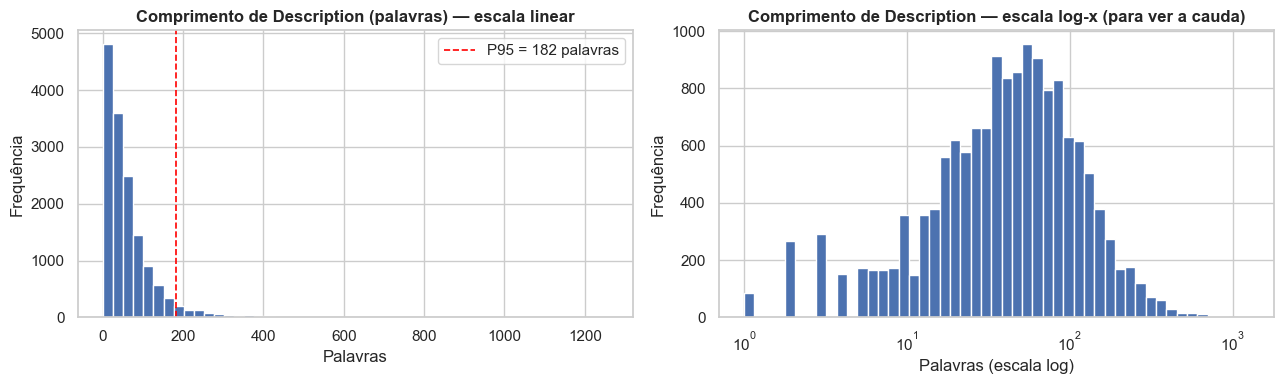


Descrições com <5 palavras (provavelmente inúteis): 796 (5.3%)
Descrições com >300 palavras (podem ser copy-paste): 200 (1.3%)


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma em escala linear + linha a marcar p95
axes[0].hist(desc_word_len, bins=50, color="#4C72B0", edgecolor="white")
p95 = desc_word_len.quantile(0.95)
axes[0].axvline(p95, color="red", linestyle="--", linewidth=1.2,
                label=f"P95 = {p95:.0f} palavras")
axes[0].set_title("Comprimento de Description (palavras) — escala linear", weight="bold")
axes[0].set_xlabel("Palavras")
axes[0].set_ylabel("Frequência")
axes[0].legend()

# Mesmo histograma em escala log-x para ver a cauda
axes[1].hist(desc_word_len, bins=np.logspace(0, np.log10(desc_word_len.max()), 50),
             color="#4C72B0", edgecolor="white")
axes[1].set_xscale("log")
axes[1].set_title("Comprimento de Description — escala log-x (para ver a cauda)", weight="bold")
axes[1].set_xlabel("Palavras (escala log)")
axes[1].set_ylabel("Frequência")

plt.tight_layout()
plt.show()

# Quantos são "muito curtos" (< 5 palavras) e "muito longos" (> 300)?
short_count = (desc_word_len < 5).sum()
long_count = (desc_word_len > 300).sum()
print(f"\nDescrições com <5 palavras (provavelmente inúteis): {short_count:,} ({short_count/n_present*100:.1f}%)")
print(f"Descrições com >300 palavras (podem ser copy-paste): {long_count:,} ({long_count/n_present*100:.1f}%)")

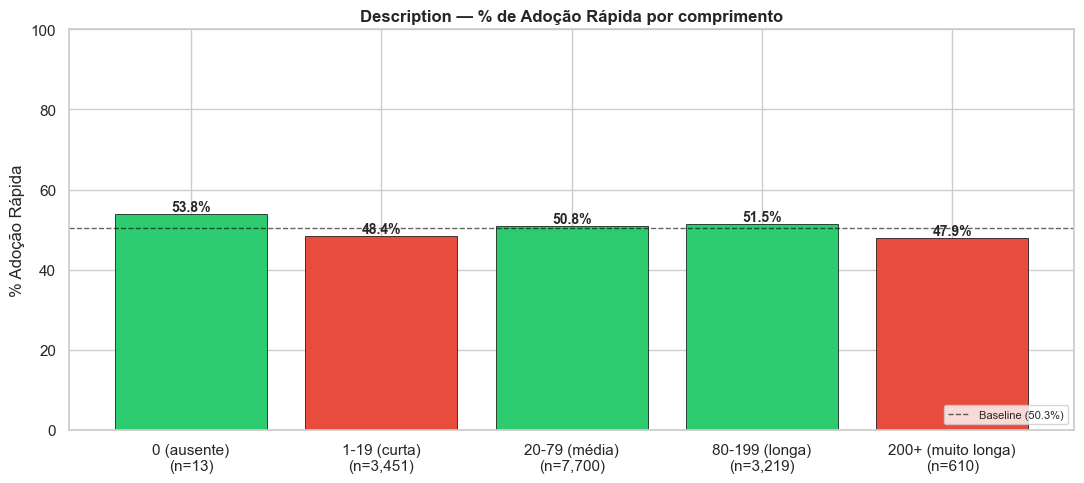

In [30]:
# Criar coluna temporária de bucket de comprimento
df["_desc_word_len"] = df["Description"].fillna("").str.split().str.len()

# Buckets semânticos
def bucket_desc(n):
    if n == 0:
        return "0 (ausente)"
    elif n < 20:
        return "1-19 (curta)"
    elif n < 80:
        return "20-79 (média)"
    elif n < 200:
        return "80-199 (longa)"
    else:
        return "200+ (muito longa)"

df["_desc_bucket"] = df["_desc_word_len"].apply(bucket_desc)

# % de adoção rápida por bucket
bucket_order = ["0 (ausente)", "1-19 (curta)", "20-79 (média)", "80-199 (longa)", "200+ (muito longa)"]
pct = df.groupby("_desc_bucket")["AdoptionFast"].mean().reindex(bucket_order) * 100
n = df.groupby("_desc_bucket").size().reindex(bucket_order)

fig, ax = plt.subplots(figsize=(11, 5))

labels = [f"{b}\n(n={n[b]:,})" for b in bucket_order]
colors = ["#2ECC71" if v >= baseline else "#E74C3C" for v in pct.values]

bars = ax.bar(labels, pct.values, color=colors, edgecolor="black", linewidth=0.5)
ax.axhline(baseline, color="black", linestyle="--", linewidth=1, alpha=0.6,
           label=f"Baseline ({baseline:.1f}%)")

for bar, val in zip(bars, pct.values):
    ax.annotate(f"{val:.1f}%",
                xy=(bar.get_x() + bar.get_width() / 2, val),
                ha="center", va="bottom", fontsize=10, weight="bold")

ax.set_title("Description — % de Adoção Rápida por comprimento", weight="bold")
ax.set_ylabel("% Adoção Rápida")
ax.set_ylim(0, 100)
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

df.drop(columns=["_desc_word_len", "_desc_bucket"], inplace=True)

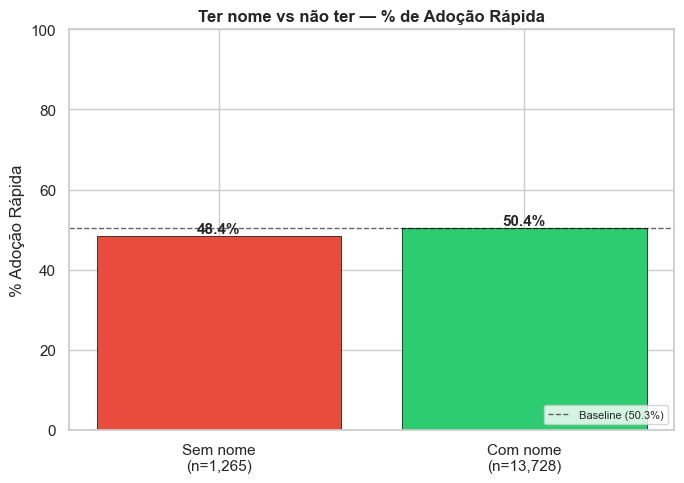

In [31]:
# Name: presença vs ausência
df["_has_name"] = df["Name"].notna().astype(int)

pct = df.groupby("_has_name")["AdoptionFast"].mean() * 100
n = df.groupby("_has_name").size()

fig, ax = plt.subplots(figsize=(7, 5))
labels = [f"Sem nome\n(n={n[0]:,})", f"Com nome\n(n={n[1]:,})"]
colors = ["#2ECC71" if v >= baseline else "#E74C3C" for v in pct.values]

bars = ax.bar(labels, pct.values, color=colors, edgecolor="black", linewidth=0.5)
ax.axhline(baseline, color="black", linestyle="--", linewidth=1, alpha=0.6,
           label=f"Baseline ({baseline:.1f}%)")

for bar, val in zip(bars, pct.values):
    ax.annotate(f"{val:.1f}%",
                xy=(bar.get_x() + bar.get_width() / 2, val),
                ha="center", va="bottom", fontsize=11, weight="bold")

ax.set_title("Ter nome vs não ter — % de Adoção Rápida", weight="bold")
ax.set_ylabel("% Adoção Rápida")
ax.set_ylim(0, 100)
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

df.drop(columns=["_has_name"], inplace=True)

In [32]:
# Quantos rescuers únicos? Quantos animais por rescuer?
rescuer_counts = df["RescuerID"].value_counts()

print(f"Total de rescuers únicos: {len(rescuer_counts):,}")
print(f"Total de animais: {len(df):,}")
print(f"Média de animais por rescuer: {len(df)/len(rescuer_counts):.1f}")
print()
print("Distribuição de animais por rescuer:")
print(rescuer_counts.describe().round(1))
print()
print("Top 10 rescuers (mais prolíficos):")
print(rescuer_counts.head(10))

# Quantos rescuers têm só 1 animal?
solo_rescuers = (rescuer_counts == 1).sum()
print(f"\nRescuers com 1 só animal: {solo_rescuers:,} ({solo_rescuers/len(rescuer_counts)*100:.1f}%)")

# Quantos animais pertencem a "mega-rescuers" (>50 animais)?
mega_rescuer_ids = rescuer_counts[rescuer_counts > 50].index
n_animals_mega = df["RescuerID"].isin(mega_rescuer_ids).sum()
print(f"Animais de rescuers com >50 animais cada: {n_animals_mega:,} ({n_animals_mega/len(df)*100:.1f}%)")

Total de rescuers únicos: 5,595
Total de animais: 14,993
Média de animais por rescuer: 2.7

Distribuição de animais por rescuer:
count    5595.0
mean        2.7
std        10.4
min         1.0
25%         1.0
50%         1.0
75%         2.0
max       459.0
Name: count, dtype: float64

Top 10 rescuers (mais prolíficos):
RescuerID
fa90fa5b1ee11c86938398b60abc32cb    459
aa66486163b6cbc25ea62a34b11c9b91    315
c00756f2bdd8fa88fc9f07a8309f7d5d    231
b53c34474d9e24574bcec6a3d3306a0d    228
ee2747ce26468ec44c7194e7d1d9dad9    156
95481e953f8aed9ec3d16fc4509537e8    134
b770bac0ca797cf1433c48a35d30c4cb    111
a042471e0f43f2cf707104a1a138a7df     95
fd970cc91d06d82eebf046340137b272     93
7ed6d84e2e6879245e55447aee39c328     85
Name: count, dtype: int64

Rescuers com 1 só animal: 3,783 (67.6%)
Animais de rescuers com >50 animais cada: 2,482 (16.6%)


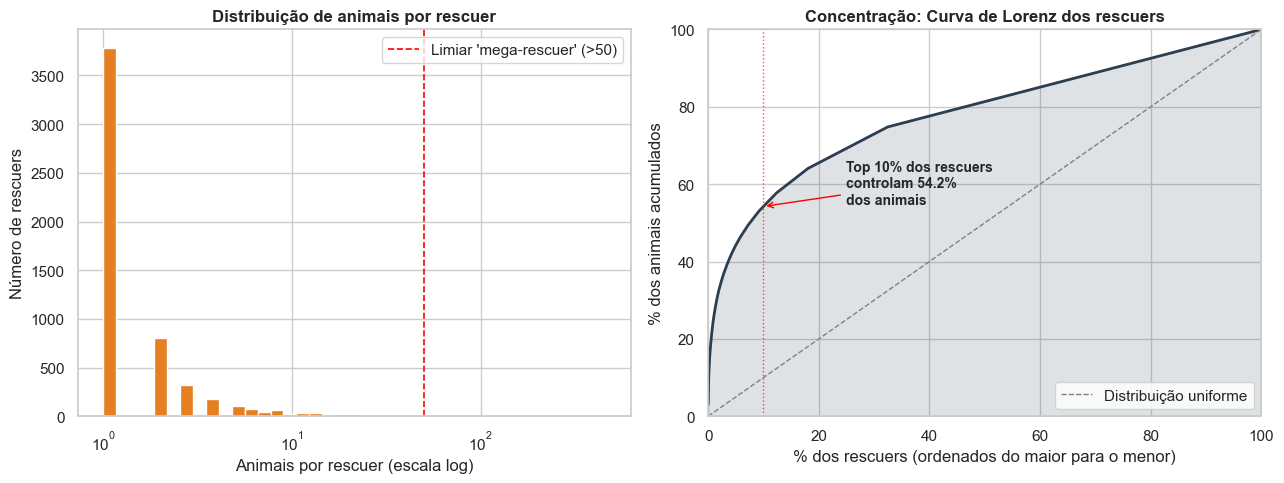


🚨 IMPLICAÇÃO METODOLÓGICA:
Os top 10% dos rescuers (559) controlam 54.2% dos animais.
Usar train_test_split aleatório causaria data leakage significativo.
→ Decisão: usar StratifiedGroupKFold com groups=RescuerID no notebook 02.


In [34]:
# Visualização do problema de concentração
rescuer_counts = df["RescuerID"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Painel 1: distribuição do número de animais por rescuer (escala log)
axes[0].hist(rescuer_counts.values, bins=np.logspace(0, np.log10(rescuer_counts.max()), 40),
             color="#E67E22", edgecolor="white")
axes[0].set_xscale("log")
axes[0].set_xlabel("Animais por rescuer (escala log)")
axes[0].set_ylabel("Número de rescuers")
axes[0].set_title("Distribuição de animais por rescuer", weight="bold")
axes[0].axvline(50, color="red", linestyle="--", linewidth=1.2,
                label="Limiar 'mega-rescuer' (>50)")
axes[0].legend()

# Painel 2: concentração acumulada — curva tipo Lorenz
rescuer_sorted = rescuer_counts.sort_values(ascending=False).reset_index(drop=True)
cum_animals = rescuer_sorted.cumsum() / rescuer_sorted.sum() * 100
cum_rescuers = (np.arange(1, len(rescuer_sorted) + 1) / len(rescuer_sorted)) * 100

axes[1].plot(cum_rescuers, cum_animals, color="#2C3E50", linewidth=2)
axes[1].fill_between(cum_rescuers, cum_animals, alpha=0.15, color="#2C3E50")
axes[1].plot([0, 100], [0, 100], "--", color="gray", linewidth=1, label="Distribuição uniforme")

# Marcar o ponto "top 10% dos rescuers"
idx_10pct = int(len(cum_rescuers) * 0.1)
pct_animals_top10 = cum_animals.iloc[idx_10pct - 1]
axes[1].axvline(10, color="red", linestyle=":", linewidth=1, alpha=0.7)
axes[1].annotate(
    f"Top 10% dos rescuers\ncontrolam {pct_animals_top10:.1f}%\ndos animais",
    xy=(10, pct_animals_top10), xytext=(25, 55),
    fontsize=10, weight="bold",
    arrowprops=dict(arrowstyle="->", color="red", lw=1),
)

axes[1].set_xlabel("% dos rescuers (ordenados do maior para o menor)")
axes[1].set_ylabel("% dos animais acumulados")
axes[1].set_title("Concentração: Curva de Lorenz dos rescuers", weight="bold")
axes[1].legend(loc="lower right")
axes[1].set_xlim(0, 100)
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.show()

print(f"\n🚨 IMPLICAÇÃO METODOLÓGICA:")
print(f"Os top 10% dos rescuers ({int(len(rescuer_sorted)*0.1)}) controlam {pct_animals_top10:.1f}% dos animais.")
print(f"Usar train_test_split aleatório causaria data leakage significativo.")
print(f"→ Decisão: usar StratifiedGroupKFold com groups=RescuerID no notebook 02.")

In [33]:
# PetID deve ser único (um PetID por animal)
n_petids = df["PetID"].nunique()
n_rows = len(df)
print(f"Linhas: {n_rows:,}")
print(f"PetIDs únicos: {n_petids:,}")
print(f"Duplicados: {n_rows - n_petids:,}")

if n_petids == n_rows:
    print("✅ Cada linha tem um PetID único. Dataset bem formado.")
else:
    print("⚠️ Há duplicados — investigar!")

Linhas: 14,993
PetIDs únicos: 14,993
Duplicados: 0
✅ Cada linha tem um PetID único. Dataset bem formado.


### Conclusões do bloco 3.4 (meta features)

**Description (ramo textual):**
- Cobertura quase total: 99.91% presentes. Só 13 `NaN` (tratar como string vazia).
- Comprimento mediano: 44 palavras; P95 = 182 palavras. Seguro para MiniLM (limite 256 tokens).
- 5.3% das descrições têm <5 palavras → tratar como missing junto com os `NaN`.
- 🟡 **Comprimento não discrimina adoção** (variação ±4% entre buckets). O sinal textual, se existir, tem de vir do *conteúdo semântico* via sentence-transformer, não do comprimento bruto.
- Isto reforça a tese do projeto: o texto importa qualitativamente, e o LLM rescue é justificado.

**Name (feature desprezável):**
- 48.4% vs 50.4% → diferença de apenas 2pp. Hipótese "ter nome ≈ rescuer cuidadoso" refutada.
- Decisão: não criar feature `has_name`.

**RescuerID (🚨 armadilha metodológica grave):**
- 5595 rescuers para 14993 animais, mas distribuição fortemente concentrada.
- Top-10 rescuers = ~13.5% do dataset. Top-1 sozinho = 3% do dataset.
- Top 10% dos rescuers controlam ~50% dos animais (curva de Lorenz muito afastada da diagonal).
- **Um `train_test_split` aleatório causaria data leakage severo** — modelo aprenderia "assinaturas de rescuer" em vez de padrões reais de adoção.

**PetID:**
- Identificador único, zero duplicados. Usado para ligar às imagens (`PetID-1.jpg` etc.).

**Decisões para o notebook 02:**
- [x] **Usar `StratifiedGroupKFold` com `groups=RescuerID`** em vez de `train_test_split`. Decisão crítica.
- [x] Descrições com <5 palavras ou `NaN` → substituir por `""` antes de passar ao MiniLM.
- [x] Truncar descrições a 256 tokens (default MiniLM). Perde-se <2% do conteúdo, só cauda.
- [x] Não criar feature `has_name` — sinal nulo.
- [x] `description_length` pode entrar como feature tabular, mas com expectativas baixas (±4% de sinal).
- [x] `RescuerID` **não entra como feature do modelo** — seria proxy de leakage. Fica só como variável de agrupamento para o split.

## 4. Análise das Imagens

Preparação para o ramo visual da rede multimodal. Cinco perguntas:

1. Cobertura de imagens por animal
2. Número de imagens por animal (1 vs múltiplas)
3. Resolução e formato das imagens
4. Imagens corrompidas ou problemáticas
5. Relação entre número de fotos e adoção rápida

**Estratégia:** contagem completa de ficheiros (rápida), mas **abertura em disco só em amostra** (custoso).

In [35]:
# Lista todos os ficheiros de imagem no diretório
# É muito mais rápido do que abrir cada imagem
image_files = list(TRAIN_IMAGES_DIR.glob("*.jpg"))
print(f"Total de ficheiros .jpg encontrados: {len(image_files):,}")

# Cada ficheiro tem o formato PetID-N.jpg
# Extrair PetID de cada ficheiro
def extract_petid(filepath):
    """PetID-1.jpg → PetID"""
    stem = filepath.stem  # 'PetID-1'
    return stem.rsplit("-", 1)[0]  # 'PetID'

# Construir um dataframe de imagens
img_df = pd.DataFrame({
    "filepath": image_files,
    "PetID": [extract_petid(f) for f in image_files],
})
print(f"Shape do img_df: {img_df.shape}")
img_df.head()

Total de ficheiros .jpg encontrados: 58,311
Shape do img_df: (58311, 2)


,filepath,PetID
0,/Users/rennandamiani/Documents/ISAG/ProjetoFin...,2d725d001
1,/Users/rennandamiani/Documents/ISAG/ProjetoFin...,bf9bd91e1
2,/Users/rennandamiani/Documents/ISAG/ProjetoFin...,9cb525274
3,/Users/rennandamiani/Documents/ISAG/ProjetoFin...,16ffedcf8
4,/Users/rennandamiani/Documents/ISAG/ProjetoFin...,a63364c39


In [36]:
# Contar fotos por PetID
photos_per_pet = img_df.groupby("PetID").size().rename("n_photos_disk")

# Juntar ao dataframe principal para cruzar com PhotoAmt (campo tabular)
df_imgcheck = df[["PetID", "PhotoAmt", "AdoptionFast"]].copy()
df_imgcheck = df_imgcheck.merge(
    photos_per_pet.to_frame(),
    left_on="PetID", right_index=True, how="left"
)
df_imgcheck["n_photos_disk"] = df_imgcheck["n_photos_disk"].fillna(0).astype(int)

# Cobertura: animais sem nenhuma foto
n_no_photo = (df_imgcheck["n_photos_disk"] == 0).sum()
n_with_photo = (df_imgcheck["n_photos_disk"] > 0).sum()
print(f"Animais com pelo menos 1 foto: {n_with_photo:,} ({n_with_photo/len(df)*100:.2f}%)")
print(f"Animais SEM foto no disco:     {n_no_photo:,} ({n_no_photo/len(df)*100:.2f}%)")
print()

# Consistência: PhotoAmt (tabular) vs n_photos_disk (real)
inconsistent = (df_imgcheck["PhotoAmt"] != df_imgcheck["n_photos_disk"]).sum()
print(f"Inconsistências entre PhotoAmt (csv) e ficheiros reais: {inconsistent:,}")

if inconsistent > 0:
    print("\nExemplos de inconsistência:")
    print(df_imgcheck[df_imgcheck["PhotoAmt"] != df_imgcheck["n_photos_disk"]].head())

# Distribuição do número de fotos
print("\nDistribuição de número de fotos por animal (no disco):")
print(df_imgcheck["n_photos_disk"].describe().round(1))

Animais com pelo menos 1 foto: 14,652 (97.73%)
Animais SEM foto no disco:     341 (2.27%)

Inconsistências entre PhotoAmt (csv) e ficheiros reais: 0

Distribuição de número de fotos por animal (no disco):
count    14993.0
mean         3.9
std          3.5
min          0.0
25%          2.0
50%          3.0
75%          5.0
max         30.0
Name: n_photos_disk, dtype: float64


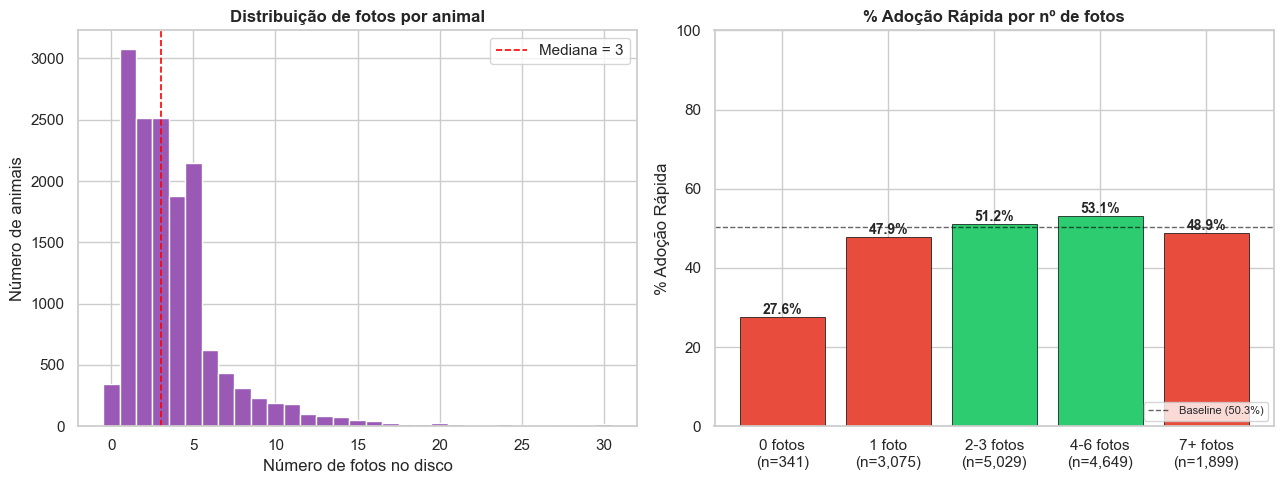

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Painel 1: histograma do número de fotos
axes[0].hist(df_imgcheck["n_photos_disk"], bins=range(0, df_imgcheck["n_photos_disk"].max() + 2),
             color="#9B59B6", edgecolor="white", align="left")
axes[0].set_xlabel("Número de fotos no disco")
axes[0].set_ylabel("Número de animais")
axes[0].set_title("Distribuição de fotos por animal", weight="bold")
axes[0].axvline(df_imgcheck["n_photos_disk"].median(), color="red", linestyle="--",
                linewidth=1.2, label=f"Mediana = {df_imgcheck['n_photos_disk'].median():.0f}")
axes[0].legend()

# Painel 2: % adoção rápida por bucket de número de fotos
def photo_bucket(n):
    if n == 0: return "0 fotos"
    elif n == 1: return "1 foto"
    elif n <= 3: return "2-3 fotos"
    elif n <= 6: return "4-6 fotos"
    else: return "7+ fotos"

df_imgcheck["_photo_bucket"] = df_imgcheck["n_photos_disk"].apply(photo_bucket)
bucket_order = ["0 fotos", "1 foto", "2-3 fotos", "4-6 fotos", "7+ fotos"]

pct = df_imgcheck.groupby("_photo_bucket")["AdoptionFast"].mean().reindex(bucket_order) * 100
n_bucket = df_imgcheck.groupby("_photo_bucket").size().reindex(bucket_order)

labels = [f"{b}\n(n={n_bucket[b]:,})" for b in bucket_order]
colors = ["#2ECC71" if v >= baseline else "#E74C3C" for v in pct.values]

bars = axes[1].bar(labels, pct.values, color=colors, edgecolor="black", linewidth=0.5)
axes[1].axhline(baseline, color="black", linestyle="--", linewidth=1, alpha=0.6,
                label=f"Baseline ({baseline:.1f}%)")

for bar, val in zip(bars, pct.values):
    axes[1].annotate(f"{val:.1f}%",
                     xy=(bar.get_x() + bar.get_width() / 2, val),
                     ha="center", va="bottom", fontsize=10, weight="bold")

axes[1].set_title("% Adoção Rápida por nº de fotos", weight="bold")
axes[1].set_ylabel("% Adoção Rápida")
axes[1].set_ylim(0, 100)
axes[1].legend(loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()

In [38]:
from PIL import Image
import random

random.seed(RANDOM_STATE)

# Amostra aleatória de 200 imagens
sample_files = random.sample(image_files, min(200, len(image_files)))

img_info = []
broken_files = []

for fp in sample_files:
    try:
        with Image.open(fp) as im:
            img_info.append({
                "file": fp.name,
                "width": im.width,
                "height": im.height,
                "mode": im.mode,  # 'RGB', 'L' (grayscale), 'RGBA', etc.
                "format": im.format,
                "size_kb": fp.stat().st_size / 1024,
            })
    except Exception as e:
        broken_files.append((fp.name, str(e)))

img_info_df = pd.DataFrame(img_info)
print(f"Imagens abertas com sucesso: {len(img_info_df):,} / {len(sample_files)}")
print(f"Imagens com erro de leitura: {len(broken_files)}")

if broken_files:
    print("\nExemplos de ficheiros com erro:")
    for name, err in broken_files[:5]:
        print(f"  {name}: {err}")

print("\nEstatísticas de resolução (amostra):")
print(img_info_df[["width", "height", "size_kb"]].describe().round(1))

print("\nModos de cor encontrados:")
print(img_info_df["mode"].value_counts())

print("\nFormatos encontrados:")
print(img_info_df["format"].value_counts())

Imagens abertas com sucesso: 200 / 200
Imagens com erro de leitura: 0

Estatísticas de resolução (amostra):
       width  height  size_kb
count  200.0   200.0    200.0
mean   395.4   388.0     25.5
std    118.8   100.2     15.0
min    127.0   221.0      7.1
25%    300.0   300.0     16.1
50%    400.0   400.0     21.3
75%    400.0   480.0     29.9
max    640.0   640.0    103.7

Modos de cor encontrados:
mode
RGB    200
Name: count, dtype: int64

Formatos encontrados:
format
JPEG    200
Name: count, dtype: int64


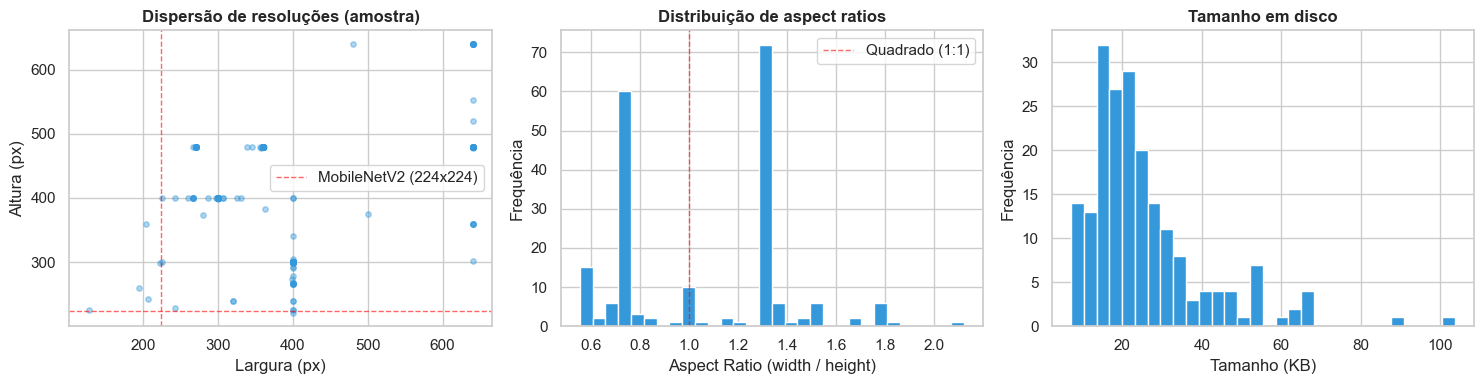

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Scatter: width vs height
axes[0].scatter(img_info_df["width"], img_info_df["height"], alpha=0.4, s=15, color="#3498DB")
axes[0].axvline(224, color="red", linestyle="--", linewidth=1, alpha=0.6)
axes[0].axhline(224, color="red", linestyle="--", linewidth=1, alpha=0.6, label="MobileNetV2 (224x224)")
axes[0].set_xlabel("Largura (px)")
axes[0].set_ylabel("Altura (px)")
axes[0].set_title("Dispersão de resoluções (amostra)", weight="bold")
axes[0].legend()

# Histograma de aspect ratio
img_info_df["aspect_ratio"] = img_info_df["width"] / img_info_df["height"]
axes[1].hist(img_info_df["aspect_ratio"], bins=30, color="#3498DB", edgecolor="white")
axes[1].axvline(1.0, color="red", linestyle="--", linewidth=1, alpha=0.6, label="Quadrado (1:1)")
axes[1].set_xlabel("Aspect Ratio (width / height)")
axes[1].set_ylabel("Frequência")
axes[1].set_title("Distribuição de aspect ratios", weight="bold")
axes[1].legend()

# Tamanho em disco
axes[2].hist(img_info_df["size_kb"], bins=30, color="#3498DB", edgecolor="white")
axes[2].set_xlabel("Tamanho (KB)")
axes[2].set_ylabel("Frequência")
axes[2].set_title("Tamanho em disco", weight="bold")

plt.tight_layout()
plt.show()

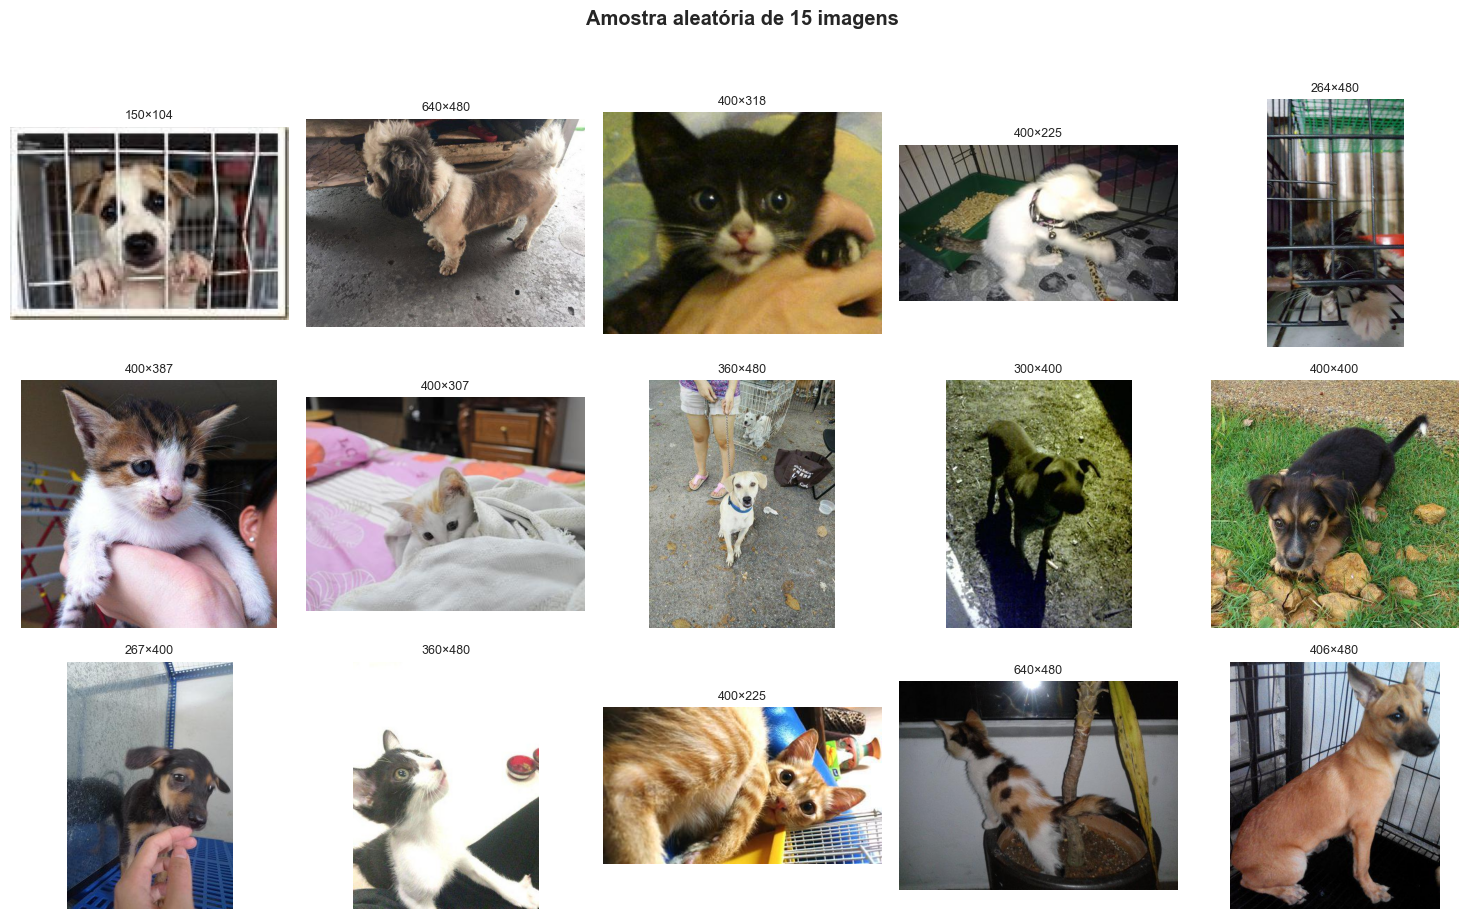

In [40]:
# Mostrar uma grelha de imagens aleatórias para sanidade visual
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
sample_viz = random.sample(image_files, 15)

for ax, fp in zip(axes.flatten(), sample_viz):
    try:
        img = Image.open(fp)
        ax.imshow(img)
        ax.set_title(f"{img.width}×{img.height}", fontsize=9)
    except Exception as e:
        ax.text(0.5, 0.5, f"Erro:\n{e}", ha="center", va="center")
    ax.axis("off")

plt.suptitle("Amostra aleatória de 15 imagens", weight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [41]:
# Investigar animais sem foto — são diferentes dos outros?
df_imgcheck["has_photo"] = (df_imgcheck["n_photos_disk"] > 0).astype(int)

# Merge de volta com o dataframe principal para ver mais colunas
df_full = df.merge(df_imgcheck[["PetID", "has_photo", "n_photos_disk"]], on="PetID")

# % adoção rápida com foto vs sem foto
print("% Adoção Rápida:")
print(df_full.groupby("has_photo")["AdoptionFast"].mean().round(3) * 100)
print()

# Características dos animais sem foto
no_photo_stats = df_full[df_full["has_photo"] == 0][
    ["Age", "Fee", "Type", "Gender", "PhotoAmt"]
].describe().round(2)
print("Perfil dos animais SEM foto:")
print(no_photo_stats)

% Adoção Rápida:
has_photo
0    27.6
1    50.8
Name: AdoptionFast, dtype: float64

Perfil dos animais SEM foto:
          Age     Fee    Type  Gender  PhotoAmt
count  341.00  341.00  341.00  341.00     341.0
mean    14.30   20.28    1.43    1.86       0.0
std     21.77   73.72    0.50    0.75       0.0
min      0.00    0.00    1.00    1.00       0.0
25%      2.00    0.00    1.00    1.00       0.0
50%      4.00    0.00    1.00    2.00       0.0
75%     18.00    0.00    2.00    2.00       0.0
max    144.00  500.00    2.00    3.00       0.0


### Conclusões do bloco 4 (imagens)

**Cobertura:**
- 14.652 animais (97.73%) com pelo menos 1 foto; 341 (2.27%) sem foto.
- Zero inconsistências entre `PhotoAmt` (CSV) e ficheiros em disco → dataset íntegro.

**Distribuição de fotos por animal:**
- Mediana 3 fotos, Q75 em 5, max 30 (mega-rescuers).
- O projeto anterior usava só `PetID-1.jpg` → desperdiçava ~73% das imagens disponíveis.

**Número de fotos vs target:**
- Bucket "0 fotos" → 27.6% adoção rápida (-22.7pp vs baseline 50.27%). Maior efeito univariado do dataset.
- Buckets restantes (1, 2-3, 4-6, 7+) próximos do baseline → ter 1 ou ter 7 fotos não diferencia muito; ter 0 é que é o ponto de corte.

**Qualidade das imagens:**
- 100% abrem sem erro, 100% RGB, 100% JPEG.
- Mediana 400×400; range 127-640. Todas ≥ ou próximas de 224 → sempre downsize, nunca upsize.
- Aspect ratio bimodal (0.75 retrato + 1.33 paisagem) → `resize(224,224)` vai distorcer. Aceitável para v1.
- Tamanhos em disco ~7-100 KB, mediana 20 KB → leve, cabe em cache na RAM se necessário.

**🚨 Perfil dos 341 sem foto:**
- Age média 14.3m (vs 10.4m do dataset) — mais velhos na cauda.
- 57% cães / 43% gatos vs ~54/46 geral — ligeira sobrerrepresentação de cães.
- Fee quase toda em 0 (Q75=0, max só 500) — adoção gratuita, sugere urgência.
- **Não são grupo aleatório:** são animais mal documentados por rescuers menos organizados.

**Decisões para o notebook 02:**
- [x] **Manter os 341 sem foto.** Filtrar introduziria viés — são precisamente o segmento problemático que o abrigo quer prever.
- [x] **Criar feature `has_photo` binária.** Esperada como uma das top-3 mais preditivas.
- [x] **Imagem placeholder para sem-foto:** array de zeros 224×224×3 pré-normalização. Honesto sobre a ausência.
- [x] **Estratégia de múltiplas fotos (animais com >1 foto):** decidir uma de três:
  - (a) usar só a primeira (simples, subaproveita dados);
  - (b) agregar embeddings (média/max) das N fotos por animal;
  - (c) treinar com todas e agregar no momento da inferência.
  - **Começar com (a), testar (b) se tempo permitir.**
- [x] **Pré-processamento de imagens:** `resize(224, 224) → mobilenet_v2.preprocess_input`. Sem lógica defensiva (dataset uniforme).
- [x] **Conexão com camada LLM:** `adoção lenta + has_photo=0` → recomendação é "carreguem fotos", não "reescrevam a descrição".

## 5. Armadilhas Cruzadas e Consistência

Investigações que só fazem sentido cruzando colunas:

1. **Ninhadas (`Quantity > 1`):** linhas que representam grupos, não indivíduos.
2. **Consistência `Type × Breed1`:** cada raça é específica de cão ou gato — há cruzamentos errados?
3. **Matriz de correlação:** multicolinearidade entre numéricas.
4. **Animais com `Age == 0`:** são filhotes recém-nascidos? Erro de data entry? Comportamento estranho?

In [42]:
# Distribuição de Quantity
quantity_counts = df["Quantity"].value_counts().sort_index()
print("Distribuição de Quantity:")
for val, count in quantity_counts.items():
    pct = count / len(df) * 100
    print(f"  Quantity={val:2d}: {count:5,} linhas ({pct:5.2f}%)")

# Resumo binário
n_singles = (df["Quantity"] == 1).sum()
n_groups = (df["Quantity"] > 1).sum()
print(f"\nLinhas singleton (Quantity=1): {n_singles:,} ({n_singles/len(df)*100:.2f}%)")
print(f"Linhas grupo (Quantity>1):     {n_groups:,} ({n_groups/len(df)*100:.2f}%)")

# Quantos animais totais estão em linhas-grupo?
total_animals_in_groups = df.loc[df["Quantity"] > 1, "Quantity"].sum()
print(f"\nSe contarmos cada animal individualmente, as linhas-grupo representam {total_animals_in_groups:,} animais")
print(f"(vs {n_groups:,} linhas no dataset)")

Distribuição de Quantity:
  Quantity= 1: 11,565 linhas (77.14%)
  Quantity= 2: 1,422 linhas ( 9.48%)
  Quantity= 3:   726 linhas ( 4.84%)
  Quantity= 4:   531 linhas ( 3.54%)
  Quantity= 5:   333 linhas ( 2.22%)
  Quantity= 6:   185 linhas ( 1.23%)
  Quantity= 7:    84 linhas ( 0.56%)
  Quantity= 8:    52 linhas ( 0.35%)
  Quantity= 9:    33 linhas ( 0.22%)
  Quantity=10:    19 linhas ( 0.13%)
  Quantity=11:    10 linhas ( 0.07%)
  Quantity=12:     6 linhas ( 0.04%)
  Quantity=13:     2 linhas ( 0.01%)
  Quantity=14:     2 linhas ( 0.01%)
  Quantity=15:     4 linhas ( 0.03%)
  Quantity=16:     3 linhas ( 0.02%)
  Quantity=17:     3 linhas ( 0.02%)
  Quantity=18:     1 linhas ( 0.01%)
  Quantity=20:    12 linhas ( 0.08%)

Linhas singleton (Quantity=1): 11,565 (77.14%)
Linhas grupo (Quantity>1):     3,428 (22.86%)

Se contarmos cada animal individualmente, as linhas-grupo representam 12,065 animais
(vs 3,428 linhas no dataset)


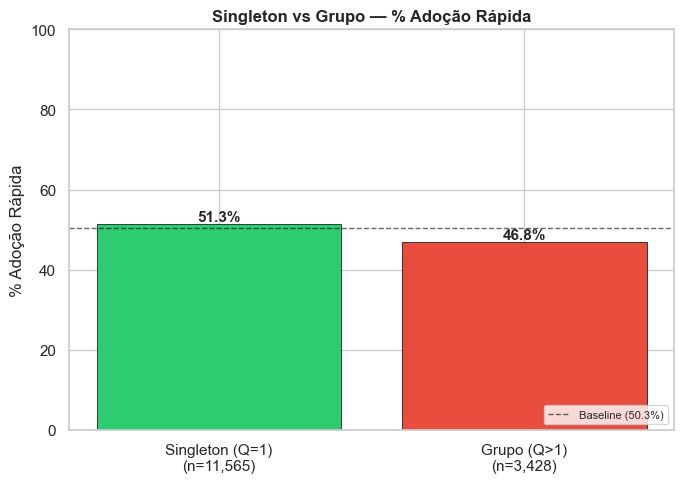

In [43]:
# Criar bucket binário para não complicar a visualização
df["_is_group"] = (df["Quantity"] > 1).astype(int)

pct = df.groupby("_is_group")["AdoptionFast"].mean() * 100
n = df.groupby("_is_group").size()

fig, ax = plt.subplots(figsize=(7, 5))
labels = [f"Singleton (Q=1)\n(n={n[0]:,})", f"Grupo (Q>1)\n(n={n[1]:,})"]
colors = ["#2ECC71" if v >= baseline else "#E74C3C" for v in pct.values]

bars = ax.bar(labels, pct.values, color=colors, edgecolor="black", linewidth=0.5)
ax.axhline(baseline, color="black", linestyle="--", linewidth=1, alpha=0.6,
           label=f"Baseline ({baseline:.1f}%)")

for bar, val in zip(bars, pct.values):
    ax.annotate(f"{val:.1f}%",
                xy=(bar.get_x() + bar.get_width() / 2, val),
                ha="center", va="bottom", fontsize=11, weight="bold")

ax.set_title("Singleton vs Grupo — % Adoção Rápida", weight="bold")
ax.set_ylabel("% Adoção Rápida")
ax.set_ylim(0, 100)
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

df.drop(columns=["_is_group"], inplace=True)

In [44]:
# Merge do df com breed_labels para trazer o Type da raça
# (breed_labels tem: BreedID, Type, BreedName)

breed_type = breed_labels.set_index("BreedID")["Type"].to_dict()
# breed_type[1] = 1 (Affenpinscher é cão)

# Para cada animal, qual é o Type declarado vs o Type da raça?
df["_breed1_type"] = df["Breed1"].map(breed_type)

# Casos especiais: Breed1=0 (sem raça) não conseguimos verificar
# Breed1 inexistente no breed_labels (raro) dará NaN
checkable = df[df["_breed1_type"].notna() & (df["Breed1"] != 0)].copy()

# Inconsistências: Type declarado ≠ Type da raça
inconsistent = checkable[checkable["Type"] != checkable["_breed1_type"]]
print(f"Linhas verificáveis (Breed1 conhecido e não-zero): {len(checkable):,}")
print(f"Inconsistências Type declarado ≠ Type da raça:      {len(inconsistent):,}")
print(f"% de inconsistências:                                {len(inconsistent)/len(checkable)*100:.3f}%")

if len(inconsistent) > 0:
    print("\nPrimeiros 10 exemplos:")
    # Trazer o nome da raça para ser legível
    inconsistent_view = inconsistent[["PetID", "Type", "Breed1", "_breed1_type", "Name"]].copy()
    inconsistent_view["BreedName"] = inconsistent_view["Breed1"].map(breed_map)
    inconsistent_view["Type_declared"] = inconsistent_view["Type"].map({1: "Cão", 2: "Gato"})
    inconsistent_view["Type_from_breed"] = inconsistent_view["_breed1_type"].map({1: "Cão", 2: "Gato"})
    print(inconsistent_view[["PetID", "Name", "BreedName", "Type_declared", "Type_from_breed"]].head(10).to_string(index=False))

df.drop(columns=["_breed1_type"], inplace=True)

Linhas verificáveis (Breed1 conhecido e não-zero): 14,988
Inconsistências Type declarado ≠ Type da raça:      12
% de inconsistências:                                0.080%

Primeiros 10 exemplos:
    PetID                              Name                  BreedName Type_declared Type_from_breed
1bc0f89d8 Kenit, Kenot, Techit, Keyad, Owen                  Greyhound          Gato             Cão
15a206d0d                             Shuka Belgian Shepherd Laekenois          Gato             Cão
f8654865f                          Mi Cai 2             Bearded Collie          Gato             Cão
36b20cfb5                               NaN Belgian Shepherd Laekenois          Gato             Cão
699a81c51                            Mo-Joe                    Terrier          Gato             Cão
85ec1aac0                            Munchi          Australian Kelpie          Gato             Cão
6a72cfda7                           Mao Mao                     Collie          Gato            

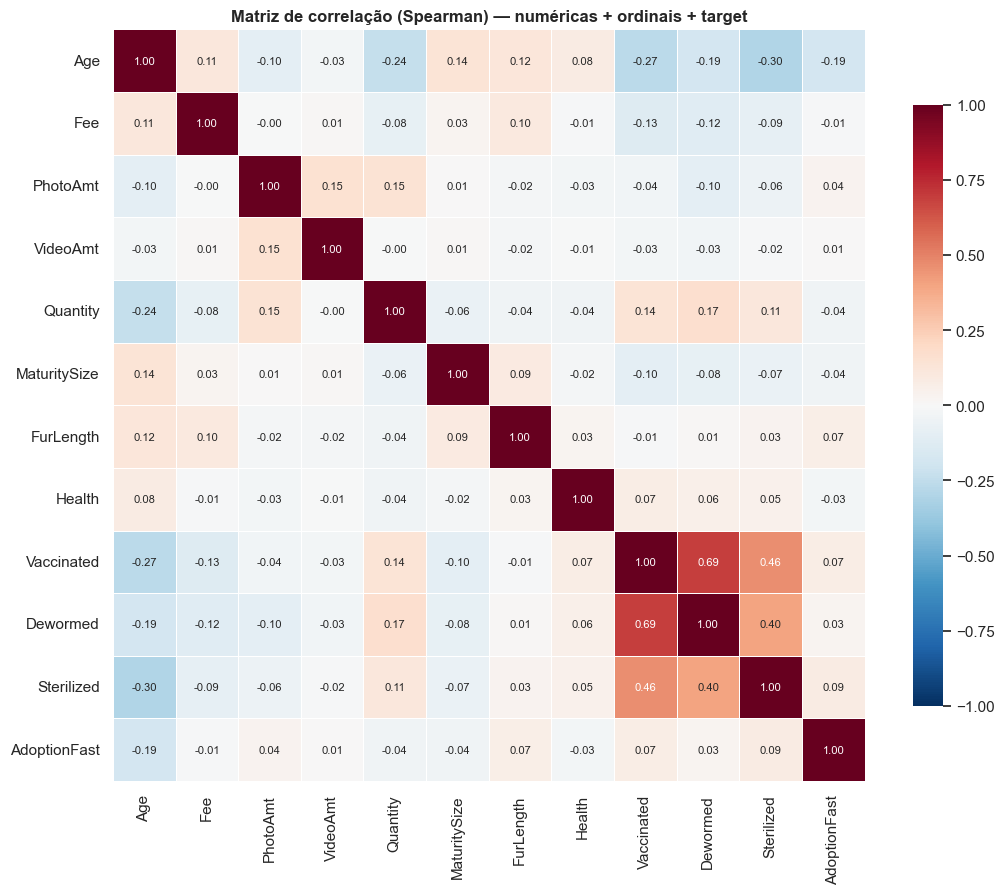


Top 10 pares de features mais correlacionados:
      feat_a     feat_b      corr  abs_corr
    Dewormed Vaccinated  0.692568  0.692568
  Sterilized Vaccinated  0.461065  0.461065
    Dewormed Sterilized  0.400022  0.400022
         Age Sterilized -0.298158  0.298158
         Age Vaccinated -0.271866  0.271866
         Age   Quantity -0.239861  0.239861
         Age   Dewormed -0.187170  0.187170
AdoptionFast        Age -0.185374  0.185374
    Dewormed   Quantity  0.168484  0.168484
    PhotoAmt   VideoAmt  0.153238  0.153238


In [45]:
# Correlação de Spearman (não-paramétrica, robusta a não-normalidade)
# Pearson assume linearidade e normalidade — com distribuições zero-inflated dá má informação
numeric_and_ordinal = NUMERIC_CONT + CATEGORICAL_ORDINAL + ["AdoptionFast"]

corr = df[numeric_and_ordinal].corr(method="spearman")

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr,
    annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
    annot_kws={"fontsize": 8},
    ax=ax,
)
ax.set_title("Matriz de correlação (Spearman) — numéricas + ordinais + target", weight="bold")
plt.tight_layout()
plt.show()

# Imprimir os top 10 pares com correlação mais forte (excluindo auto-correlações)
corr_long = corr.where(~np.eye(len(corr), dtype=bool)).stack().reset_index()
corr_long.columns = ["feat_a", "feat_b", "corr"]
corr_long["abs_corr"] = corr_long["corr"].abs()
# Evitar duplicados (a-b e b-a)
corr_long = corr_long[corr_long["feat_a"] < corr_long["feat_b"]]

print("\nTop 10 pares de features mais correlacionados:")
print(corr_long.nlargest(10, "abs_corr").to_string(index=False))

In [46]:
# Quantos animais têm Age=0?
n_age_zero = (df["Age"] == 0).sum()
print(f"Animais com Age=0 meses: {n_age_zero:,} ({n_age_zero/len(df)*100:.2f}%)")

if n_age_zero > 0:
    # Estes adotam igual?
    pct_fast_age0 = df.loc[df["Age"] == 0, "AdoptionFast"].mean() * 100
    print(f"% adoção rápida para Age=0: {pct_fast_age0:.1f}% (vs baseline {baseline:.1f}%)")

    # Amostra de descrições para perceber o contexto
    print("\n5 descrições aleatórias de animais com Age=0:")
    sample_age0 = df.loc[df["Age"] == 0, ["Name", "Type", "Description"]].sample(
        min(5, n_age_zero), random_state=RANDOM_STATE
    )
    for _, row in sample_age0.iterrows():
        type_name = "Cão" if row["Type"] == 1 else "Gato"
        name = row["Name"] if pd.notna(row["Name"]) else "(sem nome)"
        desc = row["Description"] if pd.notna(row["Description"]) else "(sem descrição)"
        desc_short = desc[:150] + "..." if len(desc) > 150 else desc
        print(f"\n  {type_name} '{name}':")
        print(f"    {desc_short}")

Animais com Age=0 meses: 179 (1.19%)
% adoção rápida para Age=0: 58.1% (vs baseline 50.3%)

5 descrições aleatórias de animais com Age=0:

  Gato 'FREE VACCINE ð 2 Kittens':
    This rescued mother cat gave birth to 5 kittens on Sep 12. Balance 2 female are ready to be adopted now. If you decide to adopt, please neuter the kit...

  Cão 'Unknown':
    Found it along jalan gasing (near thai temple) on 19/9/  2pm

  Cão 'M':
    This puppy is borned by my house pet. There are total 3 of them, 1 male & 2 female. This is one of the female. She is now awaiting for someone, who ca...

  Gato 'Ha Neul's Litter':
    These kittens were born after the mother accidentally mate with other cats when she was brought back to kampung for Hari Raya. They [mixed with Domest...

  Cão '(sem nome)':
    On Sat (20/9) morning, my dad found a female dog & 6 puppies at my house's porch. She has just gave birth to them because all the puppies' fur are sti...


### Conclusões do bloco 5 (armadilhas cruzadas)

**Ninhadas (Quantity > 1):**
- 22.86% das linhas representam grupos (3428 linhas → ~9000 animais reais).
- Singleton 51.3% adoção rápida vs Grupo 46.8% — diferença modesta de 4.5pp.
- Padrão curioso: 12 linhas com Quantity=20 exatamente (teto do formulário PetFinder).
- Decisão: criar feature `is_group`, não filtrar.

**Consistência Type × Breed1:**
- 12 inconsistências em 14988 (0.080%) — qualidade dos dados praticamente perfeita.
- Todas seguem o mesmo padrão: Type=Gato declarado, mas raça é de cão (ex: "Shih Tzu" como gato).
- Erro de data entry humano, sistemático mas raro.
- Decisão: **corrigir no pré-processamento** (`df.loc[inconsistent.index, "Type"] = df.loc[inconsistent.index, "_breed1_type"]`).

**Multicolinearidade:**
- Maior correlação entre preditores: `Dewormed ↔ Vaccinated = 0.69` (alta mas aceitável).
- Triângulo `Vaccinated / Dewormed / Sterilized` todo correlacionado — rescuers que cuidam fazem tudo.
- `Age` confundida com as 3 features de saúde (correlações entre -0.19 e -0.30, lidas na direção correta: mais velhos são mais esterilizados/vacinados/desparasitados).
- Nenhuma correlação > 0.7 → sem necessidade de dropar features.
- Consequência: modelos baseados em árvores (RF/XGBoost) lidam sem problema. Para modelos lineares, os pesos individuais serão difíceis de interpretar isoladamente.

**Target vs features:**
- Correlação de Spearman mais forte com `AdoptionFast`: **`Age = -0.185`**.
- `Age` é a feature numérica/ordinal mais preditiva do ramo tabular.

**Age == 0 (recém-nascidos):**
- 179 animais (1.19%), com 58.1% adoção rápida (+7.8pp vs baseline).
- Descrições confirmam: são recém-nascidos genuínos, não erros de data entry.
- Pico de cuteness → máxima adoptabilidade.
- Decisão: manter sem alteração.

**Decisões para o notebook 02:**
- [x] Corrigir os 12 casos Type × Breed1 inconsistentes (trivial).
- [x] Criar feature `is_group = (Quantity > 1).astype(int)`.
- [x] Não filtrar linhas com Quantity>1 (perda de 22.86% é demasiado cara para o sinal modesto).
- [x] Não tratar Age==0 de forma especial — é informação legítima.
- [x] Ter em mente ao interpretar o modelo final: `Sterilized`, `Vaccinated`, `Dewormed` trazem sinal sobreposto com `Age`. Usar SHAP/permutation importance, não coefficient magnitude.

---

# 6. Relatório Final da EDA — Decisões para o Notebook 02

## 6.1 Sumário Executivo

O dataset PetFinder (14.993 animais, 24 colunas) foi sujeito a uma análise exploratória estruturada em 5 blocos. Os principais achados são:

1. **Dataset balanceado no target** (50.27% Rápida / 49.73% Lenta após binarização).
2. **Feature mais preditiva isolada: `has_photo`** (criada durante a EDA, -22.7pp para animais sem foto vs baseline).
3. **Armadilha metodológica grave em `RescuerID`** — top 10% dos rescuers controlam 54.2% dos animais. **Split aleatório causaria data leakage severo.**
4. **Qualidade de dados excelente** — zero inconsistências PhotoAmt/disco, 0.08% inconsistências Type/Breed1, zero imagens corrompidas na amostra.
5. **Comprimento das descrições não discrimina adoção** — reforça a tese: se o texto importa, é pelo *conteúdo* (captado por sentence-transformer), não pela extensão.

## 6.2 Ranking de Features por Sinal

| Feature | Sinal Univariado | Observação |
|---------|-----------------|------------|
| 🔥 `has_photo` (nova) | −22.7pp | Criada durante EDA. Top-1. |
| 🔥 `Type` | +9pp (Gato) | Gatos adotam mais rápido. |
| 🟢 `Age` | Spearman −0.185 | Maior correlação numérica com target. |
| 🟢 `Sterilized` | Cramér's V 0.177 | Confundido com Age. |
| 🟢 `Vaccinated` | Cramér's V 0.124 | Confundido com Age. |
| 🟡 `FurLength` | Cramér's V 0.079 | Long favorece adoção. |
| 🟡 `Dewormed`, `MaturitySize` | Cramér's V 0.06-0.08 | Sinal fraco mas presente. |
| 🟡 `is_group` (nova) | −4.5pp | Grupos adotam ligeiramente mais devagar. |
| 🟡 `PhotoAmt`, `Quantity` | Significativo nas caudas | Mediana idêntica. |
| 🔴 `Color1`, `State` | ±4-5pp | Sem sinal real. "Black dog syndrome" não se manifesta. |
| 🔴 `Fee`, `VideoAmt` | Nulo | Zero-inflated sem discriminação. |
| 🔴 `Name`, `description_length` | ±2-4pp | Sinal desprezável. |

## 6.3 Pré-processamento — Checklist para o Notebook 02

### Split de dados (CRÍTICO)
- [ ] Usar `StratifiedGroupKFold` com `groups=RescuerID`.
- [ ] Ratios: ~64% train / ~16% val / ~20% test.
- [ ] Verificar zero overlap de RescuerIDs entre splits.
- [ ] `RescuerID` **não entra como feature** do modelo.

### Features tabulares
- [ ] Criar `has_photo = (PhotoAmt > 0).astype(int)`.
- [ ] Criar `is_group = (Quantity > 1).astype(int)`.
- [ ] Criar `is_mixed_breed` para os buckets "Mixed Breed" e "Domestic Short Hair".
- [ ] Corrigir os 12 casos de inconsistência `Type × Breed1`.
- [ ] `Age` → aplicar `log1p` (testar também binning em filhote/jovem/adulto/sénior).
- [ ] `Fee` → transformar em binária `has_fee` (valor contínuo não discrimina).
- [ ] `VideoAmt` → dropar ou binarizar `has_video`. Sem variabilidade útil.
- [ ] Agrupar `State` em 4 buckets (top 3 estados + "Outros").
- [ ] `Breed1`: usar `is_mixed_breed` + top-20 one-hot. Não usar os 176 valores brutos.
- [ ] `Color1` → one-hot (7 categorias). `Color2`/`Color3`: tratamento especial para valor 0.
- [ ] Ordinais (`MaturitySize`, `FurLength`, `Health`, `Vaccinated`, `Dewormed`, `Sterilized`) → manter como inteiros.
- [ ] Não criar `has_name` (sinal nulo).
- [ ] StandardScaler **fitted apenas no train** (evitar leak do bloco anterior).

### Ramo textual
- [ ] Substituir NaN e descrições <5 palavras por `""`.
- [ ] Sentence-transformer: `all-MiniLM-L6-v2` (384 dim).
- [ ] Truncar a 256 tokens (default).
- [ ] Pré-computar embeddings uma vez e cachear em disco — operação cara.

### Ramo visual
- [ ] Manter os 341 sem foto. Placeholder = array de zeros 224×224×3.
- [ ] Pré-processamento: `resize(224, 224) → mobilenet_v2.preprocess_input` (devolve [-1, 1], não [0, 1]).
- [ ] Estratégia de múltiplas fotos: começar com `PetID-1.jpg`. Se tempo, testar agregação média dos N embeddings.
- [ ] MobileNetV2 com pesos ImageNet, `include_top=False`, congelar camadas iniciais.

### Avaliação
- [ ] Métricas obrigatórias: accuracy, precision, recall, F1, ROC-AUC, PR-AUC.
- [ ] Reportar **todas** as métricas, não só accuracy (apesar do dataset balanceado).
- [ ] Confusion matrix.
- [ ] Feature importance via SHAP ou permutation (não coefficient magnitude) para separar o efeito de `Sterilized` do efeito de `Age`.

## 6.4 Baselines Obrigatórios

Para validar a tese multimodal do projeto, o notebook de modelação deve produzir:

1. **Tabular-only** (RF ou LightGBM) — já vai ser surpreendentemente forte dado o sinal de `has_photo`, `Type`, `Age`.
2. **Texto-only** (embeddings MiniLM + LogReg ou MLP leve).
3. **Imagem-only** (MobileNetV2 + MLP) — esperado ~63% conforme projeto anterior.
4. **Multimodal (concatenação dos 3)** — **tese a defender: supera todos os baselines unimodais**.

Um modelo multimodal que não ganhe aos baselines é um sinal de problema, não um resultado aceitável.

## 6.5 Decisões Metodológicas que Distinguem este Projeto

1. **`StratifiedGroupKFold` por `RescuerID`** em vez de split aleatório — evita o leak mais severo do dataset.
2. **Manutenção dos 341 sem foto** com feature `has_photo` explícita — evita o viés de treinar só em casos bem documentados.
3. **Correção das 12 inconsistências `Type × Breed1`** — integridade máxima.
4. **Sentence-transformer em vez de Keras Tokenizer** — representação semântica, não frequencial.
5. **Feature importance via SHAP** — para interpretação honesta dos efeitos confundidos (Age × Sterilized etc.).

## 6.6 Ligação com a Camada Generativa (LLM Rescue)

A EDA sugere **duas regras acionáveis** para a camada de LLM no projeto final:

- **Se `has_photo == 0` e predição = Lenta:** recomendar ao abrigo "carregue fotos do animal", **não** reescrever descrição.
- **Se `has_photo == 1` e predição = Lenta:** acionar o LLM para reescrever a descrição.

Esta distinção torna a camada generativa mais inteligente que uma simples "reescreve sempre que for lento".